# Recall Analysis Statistics

This Notebook is analysing the Data properly from our experiments: After Loading the Data and Computing all the features, here, we are making 

### Load Data

#### Parameters

In [1]:
### Imports
import matplotlib.pyplot as plt

ANNAME = "TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean" ### WORK
EXPNAME = "SecondExp"
### Parameters and Globals
DATAFOLDER = "data_second"       # Data Folder for experiment
LABELING = False                 # Labeling Mode
CLASSESS =  {1:"Focus",          # Classess Dictionairy t understand what means what
             2:"Task-Related Thoughts", 
             3: "Mind Wandering",
             4: "Mind Wandering"}

CONTINUE = True
VERBOSE = False


### Create Data Name First
CLASSN = 4                       # Number of MW Discrete Classess
SUBJECTS = ['ELMA2108','JUBE2907','SAMA1409']   
SHORTLEMMAS = True   # Whether to include Utterances that have simple to little Lemmas
VIZFOLDER = f"alt_extrF_{CLASSN}_{SHORTLEMMAS}_all"

### Adjust to current Setting 
SHORTLEMMAS = False   # Whether to include Utterances that have simple to little Lemmas
CLASSN = 4                   # Number of MW Discrete Classess

if type(SUBJECTS) == list: # If there are Subject to filterOut
    SNAME = "sFiltered"
else:
    SNAME = "sAll"

if SHORTLEMMAS:
    SHORTL = "Short"
else:
    SHORTL = "NoShort"

    
ANALYSIS_NAME = f"NewAnalysis_AutobiografyCheck_{CLASSN}_{SHORTL}_{SNAME}" # For the time when you want a different save folder


#### Load and Preprocess DFs

here we load:
- dfData - Utterances, Fragments and Lemmas
- dfAnalysis - preprocessed Sematnic Features
- dfEyeData - Occular + Behavioral Features

We also slightly preprocess our: data:
- Change column names in dfAnalysis
- normalsie MW_Estimates
- remove any unnecessery and faulty columns
- renaming Subjects and Fragments in dfAnalysis and dfData to match the dfEyeData


Finally, We Merge dfAnal;ysis with dfEyeData on trialNum and DS. checking if the joining is correct 

In [2]:
####    Load Necessery Variables and Paths:
import os 
from storyTools import loadStory,splitStoryEntity,reLabel
import pandas as pd
import numpy as np 
import pickle
from matplotlib.backends.backend_pdf import PdfPages

### General Working, Data, and Saving Path:
workingDir = os.getcwd();                                 # Current Folder
path = os.path.split(workingDir)[0] + "\\" + DATAFOLDER   # Data path
savePathRecall = os.path.join(workingDir,EXPNAME,'Recalls')       # Save Path for Recall results
loadPathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER)
savePathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',ANALYSIS_NAME)

if os.path.isdir(savePathFeatures) == 0:
    os.makedirs(savePathFeatures) # Create a directory for recall results

subjects = [f for f in os.listdir(path) if  not os.path.isfile(os.path.join(path, f))]  # get all the filenames


### Get Polish Stopwords:
with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
    polish_stopwords = set(line.strip().lower() for line in f if line.strip())





### Load Previous Excel File with Data:
dfData = pd.read_excel(os.path.join(loadPathFeatures,"data.xlsx"), index_col=0)
dfAnalysis = pd.read_excel(os.path.join(loadPathFeatures,"features.xlsx"), index_col=0)
### Load Eye and BEhavioral Data:
dfEyeData = pd.read_excel(os.path.join(os.path.join(workingDir,EXPNAME,ANNAME,'summary'),"all_data.xlsx"),header=[0, 1, 2])
dfTRFdata10s = pd.read_excel(os.path.join(workingDir,EXPNAME,ANNAME,'summary','TRF_data_10s.xlsx') ,index_col=0)
dfTRFdataAll = pd.read_excel(os.path.join(workingDir,EXPNAME,ANNAME,'summary','TRF_data_All.xlsx') ,index_col=0)

# Replace 'Unnamed' with empty string in all levels
dfEyeData.columns = pd.MultiIndex.from_tuples(
    tuple('' if "Unnamed" in str(x) else x for x in col)
    for col in dfEyeData.columns
)
dfEyeData.drop(0,axis=0,inplace=True)


### Normalise the MW Count:
for sn,s in enumerate(dfEyeData['DS'].unique()):
    m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
    st = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').std().iloc[sn])

    dfEyeData.loc[dfEyeData[('DS', '', '')] == s, ('MW_Estimate', '', '')] = (dfEyeData.loc[dfEyeData['DS'] == s, 'MW_Estimate'] - m) / st


From c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\tf_keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.

C:\Users\barak\AppData\Local\Temp\ipykernel_10648\3120713777.py:48: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
C:\Users\barak\AppData\Local\Temp\ipykernel_10648\3120713777.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  st = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').std().iloc[sn])
C:\Users\barak\AppData\Local\Temp\ipykernel_10648\3120713777.py:48: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
C

In [3]:
dfAnalysis

,Subject,Fragment,Attention,pVerbCount,pPronCount,LemmaRunsBert,LemmaRunStdsBert,LemmaRunMeansBert,LemmaRunMeansBertDiff,LemmaRunStdsBertDiff,...,WordNet_minAggrPath_Length,WordNet_minAggrPath_LengthAvg,WordNet_minAggrPath_Length_Std,WordNet_minAggrPath_Length_Mean,WordNet_minAggrPath_Length_StdAvg,WordNet_minAggrPath_Length_MeanAvg,WordNet_Steiner_EdgeN,WordNet_Steiner_NodeN,WordNet_Steiner_Weight,WordNet_Steiner_WeightAvg
0,ADNA2507,recall_JANEK_1,1,0,0,"[0.42570409178733826, -0.10708893835544586, -0...",0.179709,0.047190,-0.008610,0.226276,...,105.0,9.545455,2.659460,9.545455,0.241769,0.867769,67,68,35.20,3.200000
1,ADNA2507,recall_JANEK_10,1,1,0,"[-0.14841197431087494, -0.028562316671013832, ...",0.202910,0.127732,0.010813,0.167504,...,108.0,8.307692,2.594373,8.307692,0.199567,0.639053,59,60,38.50,2.961538
2,ADNA2507,recall_JANEK_11,1,1,0,"[-0.10210482031106949, 0.11711098998785019, 0....",0.094458,0.019848,-0.004221,0.120590,...,72.0,7.200000,3.583915,7.200000,0.358391,0.720000,34,35,21.95,2.195000
3,ADNA2507,recall_JANEK_12,1,1,0,"[-0.1099383533000946, 0.23771649599075317, 0.0...",0.104597,-0.006025,-0.004814,0.143986,...,142.0,10.923077,3.707235,10.923077,0.285172,0.840237,79,80,37.15,2.857692
4,ADNA2507,recall_JANEK_13,1,1,0,"[-0.26390838623046875, 0.10174999386072159, 0....",0.132367,0.040927,-0.017379,0.170242,...,103.0,8.583333,2.574643,8.583333,0.214554,0.715278,52,53,31.70,2.641667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,TYTO1309,recall_KAROLINA_5,1,0,2,"[-0.23040512204170227, -0.22968356311321259, -...",0.106378,-0.031186,-0.013518,0.097259,...,135.0,10.384615,2.754949,10.384615,0.211919,0.798817,58,59,36.75,2.826923
1121,TYTO1309,recall_KAROLINA_6,2,3,0,"[-0.0010257699759677052, -0.056681130081415176...",0.174199,-0.015444,0.003080,0.272222,...,142.0,7.888889,3.065729,7.888889,0.170318,0.438272,68,69,46.30,2.572222
1122,TYTO1309,recall_KAROLINA_7,2,3,1,"[-0.06281442195177078, -0.071253702044487, -0....",0.155619,0.057659,-0.000670,0.234046,...,82.0,8.200000,2.780887,8.200000,0.278089,0.820000,47,48,31.90,3.190000
1123,TYTO1309,recall_KAROLINA_8,1,2,1,"[-0.045940104871988297, -0.23782889544963837, ...",0.204536,0.057064,0.009897,0.305166,...,183.0,8.714286,3.211586,8.714286,0.152933,0.414966,65,66,48.30,2.300000


In [4]:
### TRF Data processing and merging with dfAnalysis

cols_to_skip = ['DS','trialNum','MW Estimate','Tracking']
dfTRFdata10s2 = dfTRFdata10s.rename(
    columns=lambda c: c if c in cols_to_skip else f"{c}_10s"
)

dfTRFdataAll2 = dfTRFdataAll.rename(
    columns=lambda c: c if c in cols_to_skip else f"{c}_All"
)

jointTRF = pd.merge(dfTRFdataAll2,dfTRFdata10s2,on =cols_to_skip)

TRFCols = jointTRF.drop(columns=cols_to_skip).columns
jointTRF.rename(columns={'DS' : 'Subject', 'MW Estimate' : 'MW_Estimate'},inplace = True)
jointTRF['MW_est_norm'] = jointTRF.groupby('Subject')['MW_Estimate'].transform(
         lambda x: (x - x.mean()) / x.std() ) # Transforms a DataFrame BY GROUP but returns the original Data Frame! 
jointTRF['trialNum'] = jointTRF['trialNum']+1
jointTRF

,Subject,trialNum,MW_Estimate,Tracking,r_GazeVelocity_All,z_GazeVelocity_All,rcorr_GazeVelocity_All,zcorr_GazeVelocity_All,r_LeftPupil_All,z_LeftPupil_All,...,zcorr_LeftPupil_10s,r_X_10s,z_X_10s,rcorr_X_10s,zcorr_X_10s,r_Y_10s,z_Y_10s,rcorr_Y_10s,zcorr_Y_10s,MW_est_norm
0,ADNA2507,1,37,UNTRACKED,-0.023379,-0.023383,-0.006600,-0.006600,-0.020701,-0.020704,...,-0.299159,0.029039,0.029048,0.062518,0.062600,0.125085,0.125744,-0.157473,-0.158794,1.151388
1,ADNA2507,2,1,TRACKED,0.053044,0.053093,0.019314,0.019317,-0.053635,-0.053686,...,0.287599,-0.044783,-0.044813,0.001304,0.001304,-0.320157,-0.331822,0.190632,0.192993,-0.769815
2,ADNA2507,3,2,UNTRACKED,0.055594,0.055652,-0.010542,-0.010543,0.009751,0.009751,...,-0.138304,0.146209,0.147265,0.142249,0.143220,0.117281,0.117823,0.042026,0.042050,-0.716449
3,ADNA2507,4,0,TRACKED,-0.000300,-0.000300,0.048321,0.048359,0.136391,0.137246,...,-0.099044,0.077985,0.078143,0.181012,0.183028,-0.138543,-0.139440,-0.017894,-0.017896,-0.823182
4,ADNA2507,5,27,UNTRACKED,-0.006170,-0.006170,-0.008993,-0.008993,0.023723,0.023727,...,-0.043065,0.166535,0.168101,0.270256,0.277140,0.062246,0.062327,0.093443,0.093716,0.617720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,WIJA2308,36,7,UNTRACKED,0.050400,0.050443,0.032819,0.032831,0.071193,0.071314,...,0.085331,0.016776,0.016778,-0.045319,-0.045350,0.241380,0.246239,0.165271,0.166801,1.615435
1196,WIJA2308,37,12,TRACKED,0.017472,0.017474,-0.006401,-0.006401,-0.000468,-0.000468,...,0.155200,-0.028413,-0.028421,-0.008990,-0.008990,0.385286,0.406252,0.249053,0.254403,3.090718
1197,WIJA2308,38,8,UNTRACKED,0.038685,0.038705,0.027434,0.027440,0.074474,0.074613,...,-0.062113,0.055692,0.055750,0.002560,0.002560,-0.020863,-0.020866,-0.120174,-0.120758,1.910492
1198,WIJA2308,39,9,TRACKED,0.071360,0.071481,0.046425,0.046458,0.029724,0.029733,...,0.024053,0.086255,0.086470,-0.041263,-0.041286,0.191620,0.194019,0.083998,0.084196,2.205548


In [5]:
### Load Addtional TRF features 

In [6]:
### Change the column names for something more palatable

dfAnalysis.rename(columns={'utt_leng' : 'Utterance Length',
                           'pVerbCount' : 'Personal Verb Count',
                           'pPrnCount' : 'Personal Pronoun Count',
                           'LexDivS'  : 'Subject LexDiv',
                           'LexDivSS' : 'All Data LexDiv',
                           'LemEmbBert' : 'Lemma Embeddings BERT max',
                           'LemEmbFtxt' : 'Lemma Embeddings Word2vec',
                           'TFIDFSim' : 'Lemma Embeddings TF_IDF ',
                           'NounEmb' : 'Noun Embeddings Word2vec',
                           'VerbEmb' : 'Verb Embeddings Word2vec',
                           'wmd' : 'Word Mover Distance Subject',
                           'wmdS' : 'Word Mover Distance Dataset',
                           'LemmaRunStdsBert' : 'Lemma Sim Run Stds BERT',
                           'lemmaRunMeansBert' : 'Lemma Sim Run Means BERT',
                           'LemmaRunMeansBertDiff' : 'Lemma Sim Run Means Diff BERT',
                           'LemmaRunStdsBertDiff' : 'Lemma Sim Run Stds Diff BERT',
                           'LemmaRunStdsW2v' : 'Lemma Sim Run Stds Word2vec',
                           'LemmaRunMeansW2v' : 'Lemma Sim Run Means Word2vec',
                           'LemmaRunMeansW2vDiff' : 'Lemma Sim Run Means Diff W2v',
                           'LemmaRunStdsW2vDiff' : 'Lemma Sim Run Stds Diff W2v',
                           'Focus' : 'BERTopic Focus Prob',
                           'Task-Related Thoughts' : 'BERTopic TRT Prob',
                           'Mind Wandering' : 'BERTopic MW Prob',
                           'Mind Blanking' : 'BERTopic MB Prob',
                           'FragmentSentCosSim': 'Frag-Utt Cosine Sim (Sentance) BERT',
                           'FragmentLemmaCosSim': 'Frag-Utt Cosine Sim (Lemma) BERT',
                           'FragmentSentCosSimw2v': 'Frag-Utt Cosine Sim (Sentence) w2v',
                            'FragmentLemmaCosSimw2v': 'Frag-Utt Cosine Sim (Lemma) w2v',
                            'FragmentLemmaCosSimTFIDF': 'Frag-Utt Cosine Sim (Lemma) tfif',

                           'wmdFragments': 'Frag-Utt Word Mover Distance',
                           'perpBert': 'Bert Perplexity',
                           'perpBertC': 'Bert Perplexity (Fragment Context)',
                           'perpGLM': 'GLM Perplexity ',
                           'perpGLMC': 'GLM Perplexity (Fragment Context)',
                           'LemmaWeights_minAggrPath': 'Semantic Web Weights of Utterance',
                           },inplace = True)




In [7]:
### RenameSubjects: and Rename the trialNumbers
subjPaths = [ f.name for f in os.scandir(savePathRecall) if f.is_dir() ]
import re
from itertools import zip_longest


dfAnalysis.reset_index(drop=True,inplace=True) # Reset Index to avoid issues with merging
dfData.reset_index(drop=True,inplace=True)

dfData['DS'] = dfData['Subject']
dfAnalysis['DS'] = dfData['Subject']

# Create a mapping from subject IDs to DS codes
fragmentEquivalenceDF = pd.read_excel( os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER,"fragEquiv.xlsx"), index_col=0)
for sn,s in enumerate(subjPaths):
    currSlice = dfData['Subject'] == s

    dfData['DS'][currSlice] = f'DS{int(sn+1):02d}'
    dfAnalysis['DS'][currSlice] = f'DS{int(sn+1):02d}'


# Join with DF giving the Trial Numbers
dfData = dfData.merge(fragmentEquivalenceDF,on="Fragment")        
dfAnalysis = dfAnalysis.merge(fragmentEquivalenceDF,on="Fragment")

# Drop faulty collumns
#dfAnalysis.drop(['LemEmbS','LemEmbC'],axis=1,inplace=True )

if CLASSN ==2: # Collapse Clasesess
    dfAnalysis.loc[dfAnalysis['Attention'] == 2,'Attention']= 1
    dfAnalysis.loc[dfAnalysis['Attention'] == 4,'Attention'] = 3

# Add +1 Trial to map nicely with Eye Data
dfAnalysis['trialNum'] +=1

# Sort Values not to feel lost
dfAnalysis.sort_values(by=['DS','trialNum'],inplace=True)
dfAnalysis

,Subject,Fragment,Attention,Personal Verb Count,pPronCount,LemmaRunsBert,Lemma Sim Run Stds BERT,LemmaRunMeansBert,Lemma Sim Run Means Diff BERT,Lemma Sim Run Stds Diff BERT,...,WordNet_minAggrPath_Length_Std,WordNet_minAggrPath_Length_Mean,WordNet_minAggrPath_Length_StdAvg,WordNet_minAggrPath_Length_MeanAvg,WordNet_Steiner_EdgeN,WordNet_Steiner_NodeN,WordNet_Steiner_Weight,WordNet_Steiner_WeightAvg,DS,trialNum
20,ADNA2507,recall_KAROLINA_1,3,1,1,"[-0.00974507536739111, -0.00974507536739111, 0...",0.101208,0.030596,0.010899,0.176659,...,3.405877,10.000000,0.567646,1.666667,52,53,25.85,4.308333,DS01,1
0,ADNA2507,recall_JANEK_1,1,0,0,"[0.42570409178733826, -0.10708893835544586, -0...",0.179709,0.047190,-0.008610,0.226276,...,2.659460,9.545455,0.241769,0.867769,67,68,35.20,3.200000,DS01,2
31,ADNA2507,recall_KAROLINA_2,1,1,0,"[-0.19098816812038422, 0.05463479086756706, 0....",0.153135,0.018772,-0.004101,0.263480,...,3.605551,9.000000,0.277350,0.692308,80,81,42.20,3.246154,DS01,3
11,ADNA2507,recall_JANEK_2,1,1,0,"[-0.16807855665683746, 0.1173364594578743, 0.0...",0.106970,-0.029555,-0.018374,0.155270,...,4.387482,9.000000,0.487498,1.000000,38,39,28.50,3.166667,DS01,4
33,ADNA2507,recall_KAROLINA_3,2,2,0,"[-0.14859133958816528, 0.46923428773880005, 0....",0.252790,0.106413,0.013276,0.338707,...,4.555217,9.750000,0.379601,0.812500,54,55,36.25,3.020833,DS01,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,WIJA2308,recall_JANEK_18,2,2,0,"[-0.004384653642773628, 0.1451234072446823, -0...",0.121189,-0.022001,0.007608,0.176102,...,2.802596,7.636364,0.254781,0.694215,51,52,37.50,3.409091,DS29,36
637,WIJA2308,recall_KAROLINA_19,3,1,1,"[-0.15739239752292633, -0.15350483357906342, 0...",0.114943,0.019620,0.000172,0.165864,...,2.674232,9.333333,0.222853,0.777778,54,55,29.80,2.483333,DS29,37
617,WIJA2308,recall_JANEK_19,3,1,2,"[-0.057681355625391006, 0.002345927292481065, ...",0.109892,0.020636,-0.002024,0.153020,...,3.180533,8.700000,0.159027,0.435000,71,72,53.20,2.660000,DS29,38
639,WIJA2308,recall_KAROLINA_20,2,1,1,"[-0.08673126250505447, 0.44458848237991333, -0...",0.172768,-0.023356,-0.004666,0.284233,...,3.473605,9.285714,0.248115,0.663265,52,53,35.25,2.517857,DS29,39


In [8]:
### Join TRF and dfAnalysis Matrix for Outlier amd Missing data exclusion
trfMerged = pd.merge(dfAnalysis,jointTRF,on=['Subject','trialNum'])

In [9]:
### Merge Eye Data and Utterance Data

def pad_columns(df, depth, fill=''):
    """
        Quick Function to pad one-level column DF to a preset depth adding levels
    """
    if not isinstance(df.columns, pd.MultiIndex):
        df.columns = pd.MultiIndex.from_tuples([(c,) + (fill,) * (depth - 1) for c in df.columns])
    elif df.columns.nlevels < depth:
        df.columns = pd.MultiIndex.from_tuples(
            [tuple(col) + (fill,) * (depth - len(col)) for col in df.columns]
            for col in df.columns
        )
    return df

# Pad dfAnalysis columns to 3 levels
dfAnalysis = pad_columns(dfAnalysis, 3)
# Now merge using the correct tuple for 'trialNum'
merged = dfEyeData.merge(dfAnalysis, on=[('DS', '', ''),('trialNum', '', ''),('Subject', '', '')])
merged


MW_Estimate GazeDifference Pupil_Diameter                      \
                                                  Mean                 Std   
                                              Left_Eye Right_Eye  Left_Eye   
0        0.0    1.151388      66.549382      -0.096491 -0.172199  0.116114   
1        1.0   -0.769815      44.842655      -0.166173 -0.317226  0.031314   
2        2.0   -0.716449      45.345948      -0.099478 -0.221636  0.035233   
3        3.0   -0.823182      47.772216      -0.282687 -0.350485  0.060644   
4        4.0    0.617720      54.860036      -0.116082 -0.220245  0.027706   
...      ...         ...            ...            ...       ...       ...   
1120  1155.0    1.615435      52.187201       0.026844  0.035710  0.010201   
1121  1156.0    3.090718      56.959434      -0.048244 -0.068206  0.007458   
1122  1157.0    1.910492      58.497903       0.080471  0.077752  0.018667   
1123  1158.0    2.205548      50.537350      -0.035233 -0.062044  0.007379   
1124  1159.0   -0.449961      51.838805       0.083179  0.072657  0.022118   

                                                ...  \
                    diff                   auc  ...   
     Right_Eye  Left_Eye Right_Eye    Left_Eye  ...   
0     0.087787  0.014359  0.028205 -119.473187  ...   
1     0.030663  0.063724 -0.093368 -205.623270  ...   
2     0.024322  0.040668 -0.011161 -123.234275  ...   
3     0.048683 -0.149032 -0.163326 -350.013529  ...   
4     0.024446 -0.024996 -0.032486 -143.761635  ...   
...        ...       ...       ...         ...  ...   
1120  0.012198 -0.020222 -0.040862   33.252490  ...   
1121  0.008628  0.022098  0.020378  -59.719671  ...   
1122  0.032195  0.065303  0.041999   99.610500  ...   
1123  0.009067  0.010983  0.003667  -43.607820  ...   
1124  0.035801 -0.066900 -0.083227  102.987939  ...   

     WordNet_minAggrPath_Length WordNet_minAggrPath_LengthAvg  \
                                                                
                                                                
0                          60.0                     10.000000   
1                         105.0                      9.545455   
2                         117.0                      9.000000   
3                          81.0                      9.000000   
4                         117.0                      9.750000   
...                         ...                           ...   
1120                       84.0                      7.636364   
1121                      112.0                      9.333333   
1122                      174.0                      8.700000   
1123                      130.0                      9.285714   
1124                       77.0                      7.700000   

     WordNet_minAggrPath_Length_Std WordNet_minAggrPath_Length_Mean  \
                                                                      
                                                                      
0                          3.405877                       10.000000   
1                          2.659460                        9.545455   
2                          3.605551                        9.000000   
3                          4.387482                        9.000000   
4                          4.555217                        9.750000   
...                             ...                             ...   
1120                       2.802596                        7.636364   
1121                       2.674232                        9.333333   
1122                       3.180533                        8.700000   
1123                       3.473605                        9.285714   
1124                       2.540779                        7.700000   

     WordNet_minAggrPath_Length_StdAvg WordNet_minAggrPath_Length_MeanAvg  \
                                                                            
                                                                            
0           

### Add Checks and Select Quality Data: 


In [10]:
#### QUALITY CHECKS FOR THE DATA NUMBER 
### CHECK - whether all has been merged Correctly 
keys = ["Subject", "trialNum"]

# de-dup keys (important if merged is m:1)
ana_keys = dfAnalysis[keys].drop_duplicates()
mer_keys = merged[keys].drop_duplicates()

# 1) In dfAnalysis but NOT in merged
missing_keys = (
    pd.MultiIndex.from_frame(ana_keys)
    .difference(pd.MultiIndex.from_frame(mer_keys))
)
missing_from_merged = (
    dfAnalysis.set_index(keys).loc[missing_keys].reset_index()
)

print(f"Number of absent EyeData Rows:    {len(dfEyeData) - len(dfAnalysis)}")
print(f"Number of Missed dfAnalysis Rows: {len(missing_from_merged)}")

print("===== Subject Wise Checks =====")
checks = merged[[('Subject','',''),
            ('Pupil_Diameter','Mean','Left_Eye'),
            ('Checks','', 'saccadeRate'),
            ('Checks','', 'blinkRate'),
            ('Checks','', 'goodRatioLeft'),
            ('Checks','', 'gazeRate'),
            ('Checks','', 'gazeDiff'),
            ('Blinks','', 'BlinkDuration'),
            ('Utterance Length','',''),
            ('lemmaN','','')]]
checks.columns = checks.columns.to_series().apply(''.join)
checks[['ChecksblinkRate']] = checks[['ChecksblinkRate']].apply(lambda x: x*1000*1000)
checks[['CheckssaccadeRate']] = checks[['CheckssaccadeRate']].apply(lambda x: x*1000*1000)

checks.groupby('Subject').agg('mean','std')

Number of absent EyeData Rows:    35
Number of Missed dfAnalysis Rows: 0
===== Subject Wise Checks =====


,Pupil_DiameterMeanLeft_Eye,CheckssaccadeRate,ChecksblinkRate,ChecksgoodRatioLeft,ChecksgazeRate,ChecksgazeDiff,BlinksBlinkDuration,Utterance Length,lemmaN
Subject,,,,,,,,,
ADNA2507,-0.172276,3.596103e+06,1.773401e+06,0.966448,0.131382,62.578361,145.676837,161.800000,13.875000
AGBA0708,-0.407004,3.118529e+06,1.233502e+06,0.979661,0.084130,35.972454,109.847663,147.250000,11.275000
ANBA2308,-0.340999,3.538192e+06,2.334957e+06,0.763578,0.356755,173.037583,292.574197,276.275000,20.175000
ANGU1309,-0.201925,3.218253e+06,1.480129e+06,0.947054,0.153309,128.707549,189.863728,393.875000,26.300000
ANLU2607,-0.437765,2.604729e+06,1.676756e+06,0.964613,0.204356,44.220899,197.501485,175.275000,14.450000
ANSW1409,-0.007694,2.170378e+06,1.001567e+06,0.982436,0.058496,32.679797,100.281863,194.525000,14.825000
BAZA2108,-0.153727,4.064226e+06,2.067172e+06,0.963058,0.128449,85.625438,108.690721,144.583333,10.416667
BEWA2308,-0.270069,4.132492e+06,2.240896e+06,0.852370,0.302794,132.351161,165.591241,202.100000,14.875000
EDJA1309,-0.593978,1.887039e+06,3.111512e+05,0.982237,0.028875,39.104419,176.620281,135.875000,11.975000


In [11]:
if type(SUBJECTS) == list: # If there are Subject to filterOut
    # Get all of the Rows that do not contain this subjec
    merged = merged[merged['Subject'].apply(lambda x: True if x not in SUBJECTS else False)]
if not SHORTLEMMAS:
    merged = merged[merged['lemmaN'] > 4]

In [12]:
merged

MW_Estimate GazeDifference Pupil_Diameter                      \
                                                  Mean                 Std   
                                              Left_Eye Right_Eye  Left_Eye   
0        0.0    1.151388      66.549382      -0.096491 -0.172199  0.116114   
1        1.0   -0.769815      44.842655      -0.166173 -0.317226  0.031314   
2        2.0   -0.716449      45.345948      -0.099478 -0.221636  0.035233   
3        3.0   -0.823182      47.772216      -0.282687 -0.350485  0.060644   
4        4.0    0.617720      54.860036      -0.116082 -0.220245  0.027706   
...      ...         ...            ...            ...       ...       ...   
1120  1155.0    1.615435      52.187201       0.026844  0.035710  0.010201   
1121  1156.0    3.090718      56.959434      -0.048244 -0.068206  0.007458   
1122  1157.0    1.910492      58.497903       0.080471  0.077752  0.018667   
1123  1158.0    2.205548      50.537350      -0.035233 -0.062044  0.007379   
1124  1159.0   -0.449961      51.838805       0.083179  0.072657  0.022118   

                                                ...  \
                    diff                   auc  ...   
     Right_Eye  Left_Eye Right_Eye    Left_Eye  ...   
0     0.087787  0.014359  0.028205 -119.473187  ...   
1     0.030663  0.063724 -0.093368 -205.623270  ...   
2     0.024322  0.040668 -0.011161 -123.234275  ...   
3     0.048683 -0.149032 -0.163326 -350.013529  ...   
4     0.024446 -0.024996 -0.032486 -143.761635  ...   
...        ...       ...       ...         ...  ...   
1120  0.012198 -0.020222 -0.040862   33.252490  ...   
1121  0.008628  0.022098  0.020378  -59.719671  ...   
1122  0.032195  0.065303  0.041999   99.610500  ...   
1123  0.009067  0.010983  0.003667  -43.607820  ...   
1124  0.035801 -0.066900 -0.083227  102.987939  ...   

     WordNet_minAggrPath_Length WordNet_minAggrPath_LengthAvg  \
                                                                
                                                                
0                          60.0                     10.000000   
1                         105.0                      9.545455   
2                         117.0                      9.000000   
3                          81.0                      9.000000   
4                         117.0                      9.750000   
...                         ...                           ...   
1120                       84.0                      7.636364   
1121                      112.0                      9.333333   
1122                      174.0                      8.700000   
1123                      130.0                      9.285714   
1124                       77.0                      7.700000   

     WordNet_minAggrPath_Length_Std WordNet_minAggrPath_Length_Mean  \
                                                                      
                                                                      
0                          3.405877                       10.000000   
1                          2.659460                        9.545455   
2                          3.605551                        9.000000   
3                          4.387482                        9.000000   
4                          4.555217                        9.750000   
...                             ...                             ...   
1120                       2.802596                        7.636364   
1121                       2.674232                        9.333333   
1122                       3.180533                        8.700000   
1123                       3.473605                        9.285714   
1124                       2.540779                        7.700000   

     WordNet_minAggrPath_Length_StdAvg WordNet_minAggrPath_Length_MeanAvg  \
                                                                            
                                                                            
0           

In [13]:
lemmaRunsW2v = merged['LemmaRunsW2v']
lemmaRunsBert = merged['LemmaRunsBert']

merged.drop(['LemmaRunsW2v','LemmaRunsBert'], axis=1, inplace=True)

C:\Users\barak\AppData\Local\Temp\ipykernel_10648\3700895835.py:4: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  merged.drop(['LemmaRunsW2v','LemmaRunsBert'], axis=1, inplace=True)


In [14]:
dfAnalysis['Subject'].unique()

array(['ADNA2507', 'AGBA0708', 'ANBA2308', 'ANGU1309', 'ANLU2607',
       'ANSW1409', 'BAZA2108', 'BEWA2308', 'EDJA1309', 'ELMA2108',
       'EWSI2308', 'IGWI1409', 'IZPR2608', 'JAJA2108', 'JUBE2907',
       'JUWO0708', 'KABE2308', 'KAFI2108', 'KLKR2608', 'MAMA2608',
       'MANI2607', 'MOWA1009', 'NIZA2907', 'OSJA1309', 'PASZ2608',
       'PIKR2907', 'SAMA1409', 'TYTO1309', 'WIJA2308'], dtype=object)

In [15]:
import random
from collections import Counter


import itertools

def exploreUtterances(dfData,dfAnalysis,N=5):\

    subjs = dfData['Subject'].unique()
    print("\n------------------------------------------------------------------------\n")

    for s in subjs:
        currData = dfData[dfData['Subject'] == s]
        print(f"===== Current Subject: {s} =====")
        print(currData[['Utterance','Subject']].iloc[random.sample(list(range(0,len(currData['Utterance']))),N)].to_string())
        
        subjLemmas = list(itertools.chain.from_iterable(list(currData['Lemmas'])));
        subjNouns = list(itertools.chain.from_iterable(list(currData['Nouns'])));
        subjVerbs = list(itertools.chain.from_iterable(list(currData['Verbs'])));
        lemmaN = dfAnalysis[dfAnalysis['Subject'] == s]['lemmaN']
        print(f"\nMiost Prolific Lemmas: {Counter(subjLemmas).most_common(N)}")
        print(f"Least Prolific Lemmas: {Counter(subjLemmas).most_common()[-3:]}")
        print(f"Subject Vocabulary N : {len(set(subjNouns))}")
        print(f"Subject Vocabulary V : {len(set(subjVerbs))}")
        print(f"Subject Vocabulary L : {len(set(subjLemmas))}")
        print(f"Mean Sub Lemma Number: {np.mean(lemmaN)}")
        print("\n------------------------------------------------------------------------\n")


exploreUtterances(dfData,dfAnalysis,N=5)



------------------------------------------------------------------------

===== Current Subject: ADNA2507 =====
                                                                                                                                                                                                            Utterance   Subject
36   Karolina jest zwodzona przez postać i przez lusterko, które otrzymała.  Pewnie wydarzy się coś złego i mamy jakieś takie dalsze warianty historii, które mogą się wydarzyć na podstawie książek, które czytałem.  ADNA2507
29                                                                       Wyobraziłem sobie Karoliny, która siedzi na tym stole, taka przygnębiona i takie pół światła wchodziło przez okna, taki pokój szarobury był.  ADNA2507
20                                                                                              Karolina skojarzyła mi się z Karoliną Wierzbą, którą będę dzisiaj wieczorem widział, czyli ze znajomą i w sumie tyle.  

In [16]:
### Save Merged Data 

mergedTemp = merged[['DS','trialNum','Tracking','MW_Estimate','Attention']];

mergedTemp.columns = mergedTemp.columns.get_level_values(0)
merged['Attention2'] =  merged["Attention"].apply(lambda x: 1 if x in [1,2] else 3)
merged['MW_Estimate_bin'] =  np.where(merged["MW_Estimate"] >0,1,0)

currentDf = merged[['DS','trialNum','lemmaN','Attention','Attention2','MW_Estimate_bin','MW_Estimate','Tracking','Frag-Utt Cosine Sim (Sentance) BERT','Frag-Utt Word Mover Distance']]
currentDf.columns = ['DS','trialNum','lemmaN','Attention','Attention2','MW_Estimate_bin','MW_Estimate','Tracking','SentenceBERT_frag_ut_sim','w2v_frag_ut_wmd']
currentDf = currentDf.dropna(subset=['MW_Estimate_bin', 'Tracking', 'Attention','MW_Estimate_bin','MW_Estimate','trialNum','SentenceBERT_frag_ut_sim','w2v_frag_ut_wmd'])  # Drop rows with NaN


#mergedTemp.to_csv(os.path.join(savePathFeatures,"mergedData.csv"))

In [17]:

def plotTrialTrack(m,name,grand_df,ax,titl,paramNum=[0,1,2],anlysisName = 'Tracking',firstContrast='TRACKED',lastContrast = 'UNTRACKED'):
    ### QUick Linear Model 
    quick_untracked_lm = lambda x: m.params[m.params.keys()[paramNum[0]]] + m.params[m.params.keys()[paramNum[1]]]+m.params[m.params.keys()[paramNum[2]]]*x 
    quick_tracked_lm = lambda x: m.params[m.params.keys()[paramNum[0]]] + m.params[m.params.keys()[paramNum[2]]]*x

    trialN = np.linspace(0,len(np.unique(grand_df['trialNum'])),len(np.unique(grand_df['trialNum']))+1);
    mw_est_utr = pd.Series(trialN).apply(quick_untracked_lm)
    mw_est_tr = pd.Series(trialN).apply(quick_tracked_lm)

    ax.set_title(titl)
    ax.plot(trialN,mw_est_tr,label="Tracked model slope",color="blue",linewidth=4,linestyle='--')
    ax.plot(trialN,mw_est_utr,label="Tracked model slope",color="orange",linewidth=4)
    grTr = grand_df[[name,'trialNum',anlysisName]].groupby([anlysisName,'trialNum'])
    from scipy.stats import t

    # --- pieces from the fitted model ---
    Vbeta  = m.cov_params().loc[m.params.index, m.params.index]  # Cov(beta)
    tval   = t.ppf(0.975, df=m.df_resid)                         # 95% PI; change if needed

    # --- build X matrices consistent with your lambdas: [1, Tracking, trialNum] ---
    pnames = list(m.params.index)                # keeps exact column order used by model
    col = {name:i for i, name in enumerate(pnames)}

    def build_X(tracking): # Build simple model matrix (for tracked and untracked separately)
        X = np.zeros((len(trialN), len(pnames)))
        # these names match the terms in your formula
        X[:, col.get('Intercept', 0)] = 1.0
        if anlysisName == "Tracking":
            ttr =  'Tracking[T.UNTRACKED]'
        else:
            ttr =  'C(Attention)[T.3]'

        if ttr in col: X[:, col[ttr]] = tracking
        if 'trialNum' in col: X[:, col['trialNum']] = trialN
        return X

    X_tr  = build_X(1.0)   # tracked
    X_un  = build_X(0.0)   # untracked
    # --- se of mean and se of prediction at each trial ---
    se_mean_tr = np.sqrt(np.einsum('ij,jk,ik->i', X_tr, Vbeta.values, X_tr))
    se_mean_un = np.sqrt(np.einsum('ij,jk,ik->i', X_un, Vbeta.values, X_un))


    # --- add ribbons using your lambdas' fitted lines ---
    ax.fill_between(trialN, mw_est_tr  - tval*se_mean_tr, mw_est_tr  + tval*se_mean_tr,
                    color='mediumslateblue', alpha=0.25, label='TRACKED 95% PI')
    ax.fill_between(trialN, mw_est_utr - tval*se_mean_un, mw_est_utr + tval*se_mean_un,
                color='moccasin', alpha=0.25, label='UNTRACKED 95% PI')


    ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue',linewidth=5)
    ax.scatter(grTr.mean().loc[lastContrast].index,grTr.mean().loc[lastContrast],label="Subj Mean Untracked",color = 'orange',linewidth=5)
    ax.set_xlabel="Trial Number"
    ax.legend()

## Analysis:

### 1. BERT Sentence Cosine Similarity:  Story Fragment vs Current Thoughts


#### 1.1 Cos Sim  ~ Cued/Uncued + Lemma N + trialNum 


In [18]:
import statsmodels.formula.api as smf

from analysisFunctions import plot_pupil_vs_mw


print("\n\n=============================================================")
print(f"======== Test for MW Estimate vs {'SentenceBERT_frag_ut_sim'} =======")
print("=============================================================\n")


# Fit the mixed effects model
m1 = smf.mixedlm("SentenceBERT_frag_ut_sim ~ Tracking +trialNum +lemmaN ", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()
print(m1.summary())  # ≈ summary(lm(...)) in R






======== Test for MW Estimate vs SentenceBERT_frag_ut_sim =======

                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: SentenceBERT_frag_ut_sim
No. Observations: 1002    Method:             REML                    
No. Groups:       26      Scale:              0.0073                  
Min. group size:  31      Log-Likelihood:     985.8816                
Max. group size:  40      Converged:          Yes                     
Mean group size:  38.5                                                
-----------------------------------------------------------------------
                        Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------------------
Intercept                0.257     0.014  17.899  0.000   0.229   0.286
Tracking[T.UNTRACKED]   -0.028     0.005  -5.137  0.000  -0.038  -0.017
trialNum                -0.001     0.000  -3.252  0.001  -0.001  -0.000
lemmaN             

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### 1.2 Cos Sim  ~ MW Estimate + Lemma N + trialNum 


In [19]:
import statsmodels.formula.api as smf

from analysisFunctions import plot_pupil_vs_mw


print("\n\n=============================================================")
print(f"======== Test for MW Estimate vs {'SentenceBERT_frag_ut_sim'} =======")
print("=============================================================\n")

# Create the DataFrame and transpose it

# Clean the data
currentDf = currentDf.dropna(subset=['MW_Estimate_bin', 'Tracking', 'trialNum','SentenceBERT_frag_ut_sim','w2v_frag_ut_wmd'])  # Drop rows with NaN


# Fit the mixed effects model
m2 = smf.mixedlm("SentenceBERT_frag_ut_sim ~ C(Attention2)  + trialNum", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()
print(m2.summary())  # ≈ summary(lm(...)) in R





======== Test for MW Estimate vs SentenceBERT_frag_ut_sim =======

                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: SentenceBERT_frag_ut_sim
No. Observations: 1002    Method:             REML                    
No. Groups:       26      Scale:              0.0073                  
Min. group size:  31      Log-Likelihood:     995.5603                
Max. group size:  40      Converged:          Yes                     
Mean group size:  38.5                                                
-----------------------------------------------------------------------
                        Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------------------
Intercept                0.274     0.012  23.532  0.000   0.251   0.297
C(Attention2)[T.3]      -0.043     0.007  -6.237  0.000  -0.056  -0.029
trialNum                -0.001     0.000  -3.135  0.002  -0.001  -0.000
DS Var             

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### 1.3 Cos Sim  ~ MW_Estimate_bin + Lemma N + trialNum 


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)




======== Test for MW Estimate vs SentenceBERT_frag_ut_sim =======

                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: SentenceBERT_frag_ut_sim
No. Observations: 1002    Method:             REML                    
No. Groups:       26      Scale:              0.0075                  
Min. group size:  31      Log-Likelihood:     976.6122                
Max. group size:  40      Converged:          Yes                     
Mean group size:  38.5                                                
-------------------------------------------------------------------------
                Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept        0.239       0.014    16.817    0.000     0.211     0.267
MW_Estimate     -0.008       0.003    -2.980    0.003    -0.014    -0.003
trialNum        -0.001       0.000    -3.031    0.002    -0.001    -0.000
lemmaN 

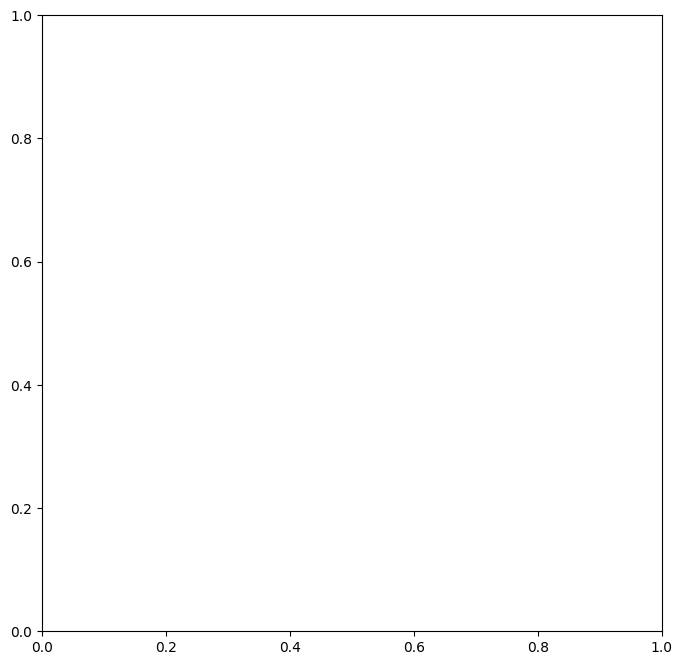

In [20]:
import statsmodels.formula.api as smf

from analysisFunctions import plot_pupil_vs_mw


print("\n\n=============================================================")
print(f"======== Test for MW Estimate vs {'SentenceBERT_frag_ut_sim'} =======")
print("=============================================================\n")


# Fit the mixed effects model
m3 = smf.mixedlm("SentenceBERT_frag_ut_sim ~ MW_Estimate +trialNum+lemmaN", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()
print(m3.summary())  # ≈ summary(lm(...)) in R
fig, ax = plt.subplots(figsize=(8, 8))


#plotTrialTrack(m,"SentenceBERT_frag_ut_sim",currentDf,ax,titl=f" {'SentenceBERT_frag_ut_sim'} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})",anlysisName = 'MW_Estimate_bin',firstContrast=1,lastContrast = 0)



In [21]:
def diffRainPlot(
    df, x, y,
    x2=None,  # <-- drugi zestaw (np. 'Attention2')
    ax=None,
    title=None,
    order=None,
    gap=0.4
):
    from matplotlib import pyplot as plt
    import seaborn as sns
    import numpy as np
    import matplotlib.colors as mcolors
    from matplotlib.ticker import MaxNLocator


    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    if order is None:
        order = list(df[x].unique())

    # --- PALETY ---
    main_palette = ['orange', 'blue', 'red', 'green']
    violin_palette = ['moccasin', 'mediumslateblue', 'lightcoral', 'lightgreen']

    # =========================
    # FUNKCJA RYSUJĄCA JEDEN SET
    # =========================
    def draw_block(x_var, offset_idx):
        sns.violinplot(
            data=df,
            x=x_var,
            y=y,
            order=order,
            palette=violin_palette[:len(order)],
            density_norm='width',
            inner=None,
            ax=ax
        )

        sns.boxplot(
            data=df,
            x=x,
            y=y,
            order=order,
            width=0.05,
            showcaps=True,
            boxprops=dict(linewidth=2.5),   # <- było 1
            medianprops=dict(color='black', linewidth=3),
            whiskerprops=dict(color='black', linewidth=2.5),
            capprops=dict(color='black', linewidth=2.5),
            flierprops=dict(marker='o', markersize=3, linestyle='none'),
            ax=ax,
            zorder=5
        )

        # kolorowanie boxów
        for i, artist in enumerate(ax.patches[-len(order):]):
            artist.set_facecolor(main_palette[i])
            artist.set_edgecolor("black")

        return offset_idx

    # =========================
    # RYSOWANIE
    # =========================
    draw_block(x, 0)

    if x2 is not None:
        draw_block(x2, 1)

    # =========================
    # PRZESUNIĘCIA (dla wszystkich elementów)
    # =========================
    centers = np.arange(len(order))
    mid = np.mean(centers)
    new_centers = mid + (centers - mid) * gap
    shifts = new_centers - centers

    # violiny
    for i, violin in enumerate(ax.collections[:len(order)]):
        for path in violin.get_paths():
            path.vertices[:, 0] += shifts[i]

    # boxy
    for i, patch in enumerate(ax.patches[-len(order):]):
        path = patch.get_path()
        path.vertices[:, 0] += shifts[i]

    # linie
    for line in ax.lines:
        xdata = line.get_xdata()
        if len(xdata) == 0:
            continue
        mean_x = np.mean(xdata)
        idx = int(np.argmin(np.abs(centers - mean_x)))
        line.set_xdata(xdata + shifts[idx])

    # =========================
    # HALF VIOLIN
    # =========================
    for i, violin in enumerate(ax.collections[:len(order)]):
        path = violin.get_paths()[0]
        bbox = path.get_extents()
        x0, y0, width, height = bbox.bounds

        if i == 0:
            violin.set_clip_path(
                plt.Rectangle((x0 + width/2, y0), width/2, height, transform=ax.transData)
            )
        else:
            violin.set_clip_path(
                plt.Rectangle((x0, y0), width/2, height, transform=ax.transData)
            )

    # =========================
    # OŚ Y – ticki + MARKI
    # =========================
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # mniej ticków

    ax.tick_params(
        axis='y',
        which='major',
        length=6,   # długość kreski
        width=1.5,
        labelsize=20
    )

    # =========================
    # USUWANIE X TICKS
    # =========================
    ax.set_xticks([])

    # =========================
    # LEGENDA
    # =========================
    handles = []
    for i, label in enumerate(order):
        handles.append(
            plt.Line2D([0], [0], color=main_palette[i], lw=4, label=label)
        )
    ax.legend(handles=handles, fontsize=14)

    # =========================
    # LABELS
    # =========================
    ax.set_xlabel(x, fontsize=25)
    ax.set_ylabel(y, fontsize=25)

    if title:
        ax.set_title(title, fontsize=27)

    return ax

In [22]:
merged.columns.to_list()

[('', '', ''),
 ('MW_Estimate', '', ''),
 ('GazeDifference', '', ''),
 ('Pupil_Diameter', 'Mean', 'Left_Eye'),
 ('Pupil_Diameter', 'Mean', 'Right_Eye'),
 ('Pupil_Diameter', 'Std', 'Left_Eye'),
 ('Pupil_Diameter', 'Std', 'Right_Eye'),
 ('Pupil_Diameter', 'diff', 'Left_Eye'),
 ('Pupil_Diameter', 'diff', 'Right_Eye'),
 ('Pupil_Diameter', 'auc', 'Left_Eye'),
 ('Pupil_Diameter', 'auc', 'Right_Eye'),
 ('Tracking', '', ''),
 ('DS', '', ''),
 ('trialNum', '', ''),
 ('Checks', '', 'goodRatioLeft'),
 ('Checks', '', 'goodRatioRight'),
 ('Checks', '', 'goodPupRatioLeft'),
 ('Checks', '', 'goodPupRatioRight'),
 ('Checks', '', 'gazeDiff'),
 ('Checks', '', 'gazeRate'),
 ('Checks', '', 'pupilDiff'),
 ('Checks', '', 'meanEyeDiff'),
 ('Checks', '', 'saccadeRate'),
 ('Checks', '', 'blinkRate'),
 ('Saccades', '', 'SaccDistance'),
 ('Saccades', '', 'SaccNumber'),
 ('Saccades', '', 'SaccVelocity'),
 ('Saccades', '', 'SaccVelocitySd'),
 ('Saccades', '', 'SaccAmplitude'),
 ('Saccades', '', 'SaccAmplitudeSd'),

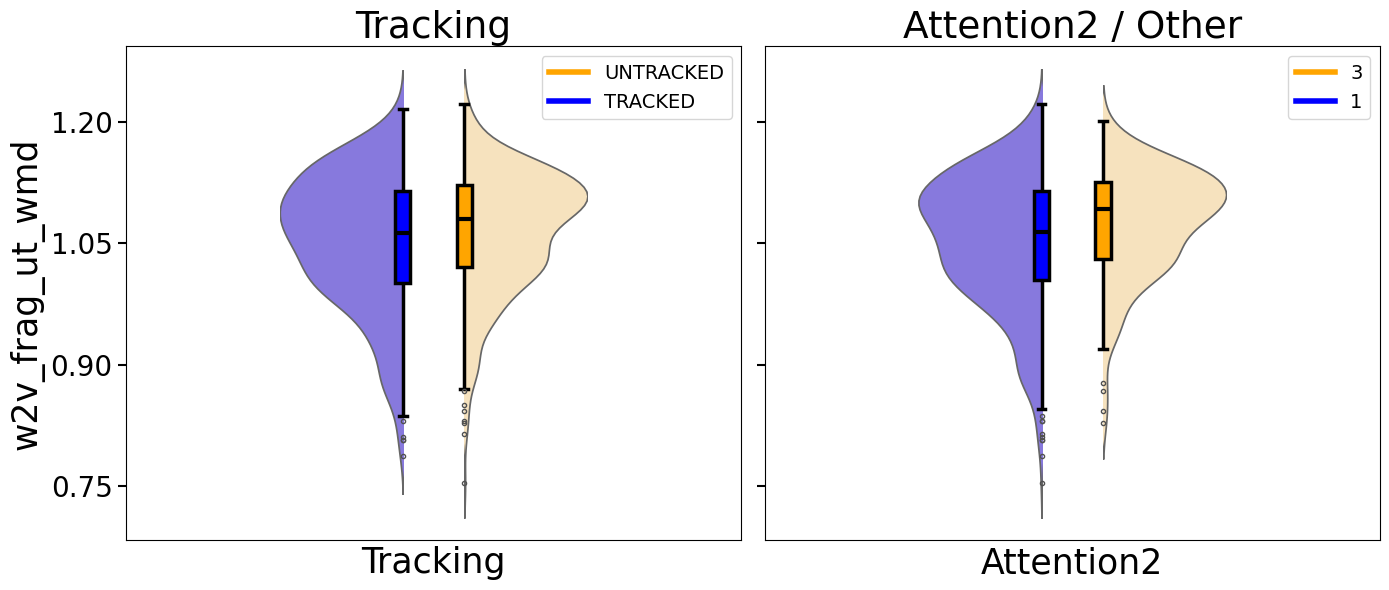

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
diffRainPlot(
    df=currentDf,
    x='Tracking',
    y='w2v_frag_ut_wmd',
    ax=axes[0],
    title='Tracking',
    gap=-0.2
)

diffRainPlot(
    df=currentDf,
    x='Attention2',
    y='w2v_frag_ut_wmd',
    ax=axes[1],
    title='Attention2 / Other',
    gap=-0.2

)

plt.tight_layout()
plt.savefig(os.path.join(savePathFeatures,"w2v_frag_ut_wmd.svg"), dpi=300, bbox_inches='tight')

In [24]:
currentDf_pl = currentDf


m11 = smf.mixedlm("SentenceBERT_frag_ut_sim ~ MW_Estimate +trialNum+lemmaN", data=currentDf_pl,
                groups="DS",  # Random intercept
                ).fit()

m11.summary()

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                Mixed Linear Model Regression Results
======================================================================
Model:            MixedLM Dependent Variable: SentenceBERT_frag_ut_sim
No. Observations: 1002    Method:             REML                    
No. Groups:       26      Scale:              0.0075                  
Min. group size:  31      Log-Likelihood:     976.6122                
Max. group size:  40      Converged:          Yes                     
Mean group size:  38.5                                                
-------------------------------------------------------------------------
                Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept        0.239       0.014    16.817    0.000     0.211     0.267
MW_Estimate     -0.008       0.003    -2.980    0.003    -0.014    -0.003
trialNum        -0.001       0.000    -3.031    0.002    -0.001    -0.000
lemmaN           0.002       0.001     2.923    0.003     0.001     0.003
DS Var           0.003       0.009                                       
======================================================================

"""

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

def plot_mw_predicted(
    m,
    df,
    ax=None,
    target='MW_Estimate',
    yvar='w2v_frag_ut_wmd',
    binwidth=0.2
):
    # ===== STYLE (MATCH plotTrialTrack) =====
    title_fs = 28
    label_fs = 24
    tick_fs = 20
    legend_fs = 15

   

    # ===== GRID =====
    x = np.linspace(df[target].min(), df[target].max(), 100)

    trial_mean = df['trialNum_centered'].mean()
    lemma_mean = df['lemmaN_centered'].mean()

    # ===== DESIGN MATRIX =====
    pnames = list(m.params.index)
    col = {name: i for i, name in enumerate(pnames)}

    X = np.zeros((len(x), len(pnames)))

    if 'Intercept' in col:
        X[:, col['Intercept']] = 1
    if 'MW_Estimate' in col:
        X[:, col['MW_Estimate']] = x
    if 'trialNum_centered' in col:
        X[:, col['trialNum_centered']] = trial_mean
    if 'lemmaN_centered' in col:
        X[:, col['lemmaN_centered']] = lemma_mean

    # ===== PREDICTION =====
    beta = m.params.values
    y_pred = X @ beta

    # ===== SE =====
    Vbeta = m.cov_params().loc[pnames, pnames].values
    se_mean = np.sqrt(np.einsum('ij,jk,ik->i', X, Vbeta, X))

    tval = t.ppf(0.975, df=m.df_resid)

    # ===== LINE (MATCH STYLE) =====
    ax.plot(
        x,
        y_pred,
        color='blue',
        label='Model prediction',
        linewidth=3
    )

    # ===== CI =====
    ax.fill_between(
        x,
        y_pred - tval * se_mean,
        y_pred + tval * se_mean,
        color='mediumslateblue',
        alpha=0.25,
        label='95% CI (mean)'
    )

    # ===== BINNED RESIDUALS =====
    df2 = df.copy()

    df2['y_resid'] = (
        df2[yvar]
        - m.params['trialNum_centered'] * df2['trialNum_centered']
        - m.params['lemmaN_centered'] * df2['lemmaN_centered']
    )

    bins = np.arange(
        df2[target].min(),
        df2[target].max() + binwidth,
        binwidth
    )

    df2['binned'] = pd.cut(df2[target], bins)

    grouped = df2.groupby('binned').agg(
        x=(target, 'mean'),
        y=('y_resid', 'mean'),
        sd=('y_resid', 'std')
    ).dropna()

    grouped['bin_center'] = grouped.index.map(lambda x: x.mid)

    ax.errorbar(
        grouped['bin_center'],
        grouped['y'],
        yerr=grouped['sd'],
        fmt='o',
        color='orange',
        ecolor='orange',
        elinewidth=2,
        capsize=4,
        markersize=10,
        label='Binned residuals ± SD'
    )

    # ===== STYLE MATCH (plotTrialTrack EXACT FEEL) =====
    ax.set_title("Similarity ~ MW Estimate", fontsize=title_fs)
    ax.set_xlabel(target, fontsize=label_fs)
    ax.set_ylabel(yvar, fontsize=label_fs)

    ax.tick_params(axis='both', labelsize=tick_fs)
    ax.legend(fontsize=legend_fs)

    return ax

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

def plot_mw_predicted_cloud(
    m,
    df,
    ax=None,
    target='MW_Estimate',
    yvar='w2v_frag_ut_wmd',
    binwidth=0.2
):
    # ===== STYLE =====
    title_fs = 28
    label_fs = 24
    tick_fs = 20
    legend_fs = 15

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # ===== GRID =====
    x = np.linspace(df[target].min(), df[target].max(), 100)

    trial_mean = df['trialNum_centered'].mean()
    lemma_mean = df['lemmaN_centered'].mean()

    # ===== DESIGN MATRIX =====
    pnames = list(m.params.index)
    col = {name: i for i, name in enumerate(pnames)}

    X = np.zeros((len(x), len(pnames)))

    if 'Intercept' in col:
        X[:, col['Intercept']] = 1
    if 'MW_Estimate' in col:
        X[:, col['MW_Estimate']] = x
    if 'trialNum_centered' in col:
        X[:, col['trialNum_centered']] = trial_mean
    if 'lemmaN_centered' in col:
        X[:, col['lemmaN_centered']] = lemma_mean

    # ===== PREDICTION =====
    beta = m.params.values
    y_pred = X @ beta

    # ===== SE =====
    Vbeta = m.cov_params().loc[pnames, pnames].values
    se_mean = np.sqrt(np.einsum('ij,jk,ik->i', X, Vbeta, X))

    tval = t.ppf(0.975, df=m.df_resid)

    # ===== RAW DATA (NOWE) =====
    ax.scatter(
        df[target],
        df[yvar],
        color='black',
        alpha=0.10,
        s=12,
        label='Raw data'
    )

    # ===== LINE =====
    ax.plot(
        x,
        y_pred,
        color='blue',
        label='Model prediction',
        linewidth=3
    )

    # ===== CI =====
    ax.fill_between(
        x,
        y_pred - tval * se_mean,
        y_pred + tval * se_mean,
        color='mediumslateblue',
        alpha=0.25,
        label='95% CI (mean)'
    )

    # ===== BINNED RESIDUALS =====
    df2 = df.copy()

    df2['y_resid'] = (
        df2[yvar]
        - m.params['trialNum_centered'] * df2['trialNum_centered']
        - m.params['lemmaN_centered'] * df2['lemmaN_centered']
    )

    bins = np.arange(
        df2[target].min(),
        df2[target].max() + binwidth,
        binwidth
    )

    df2['binned'] = pd.cut(df2[target], bins)

    grouped = df2.groupby('binned').agg(
        y=('y_resid', 'mean'),
        sd=('y_resid', 'std')
    ).dropna()

    grouped['bin_center'] = grouped.index.map(lambda x: x.mid)

    ax.errorbar(
        grouped['bin_center'],
        grouped['y'],
        yerr=grouped['sd'],
        fmt='o',
        color='orange',
        ecolor='orange',
        elinewidth=2,
        capsize=4,
        markersize=10,
        label='Binned residuals ± SD'
    )

    # ===== STYLE =====
    ax.set_title("Similarity ~ MW Estimate", fontsize=title_fs)
    ax.set_xlabel(target, fontsize=label_fs)
    ax.set_ylabel(yvar, fontsize=label_fs)

    ax.tick_params(axis='both', labelsize=tick_fs)
    ax.legend(fontsize=legend_fs)

    return ax

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: w2v_frag_ut_wmd
No. Observations: 972     Method:             REML           
No. Groups:       26      Scale:              0.0027         
Min. group size:  30      Log-Likelihood:     1430.3020      
Max. group size:  40      Converged:          Yes            
Mean group size:  37.4                                       
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          1.060    0.009 119.364 0.000  1.043  1.077
MW_Estimate        0.007    0.002   3.501 0.000  0.003  0.012
trialNum_centered  0.000    0.000   1.416 0.157 -0.000  0.000
lemmaN_centered   -0.006    0.000 -17.322 0.000 -0.006 -0.005
DS Var             0.002    0.011                            



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: SentenceBERT_frag_ut_sim
No. Observations: 972     Method:             REML                    
No. Groups:       26      Scale:              0.0074                  
Min. group size:  30      Log-Likelihood:     950.0357                
Max. group size:  40      Converged:          Yes                     
Mean group size:  37.4                                                
------------------------------------------------------------------------
                    Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept            0.250      0.010   24.049   0.000    0.229    0.270
MW_Estimate         -0.010      0.003   -2.775   0.006   -0.017   -0.003
trialNum_centered   -0.001      0.000   -2.943   0.003   -0.001   -0.000
lemmaN_centered      0.002      0.001    3.124   0.002    0.001    0.003
DS Var   

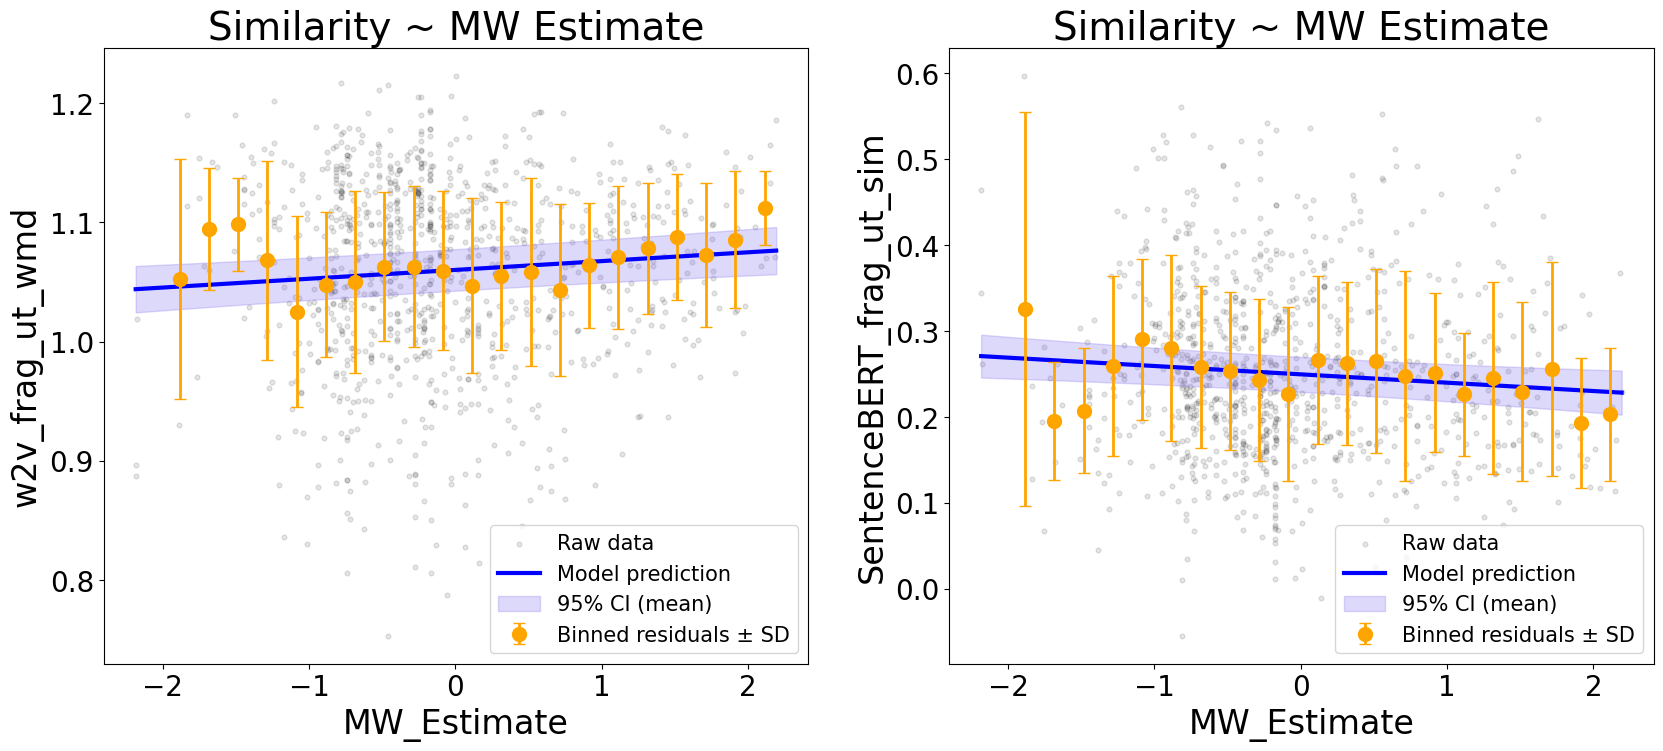

In [27]:
currentDf_pl = currentDf.copy()

currentDf_pl = currentDf_pl[(currentDf_pl['MW_Estimate'] < 2.2) & (currentDf_pl['MW_Estimate'] >-2.2)]

currentDf_pl['trialNum_centered'] = currentDf_pl['trialNum'] - currentDf_pl['trialNum'].mean()
currentDf_pl['lemmaN_centered'] = currentDf_pl['lemmaN'] - currentDf_pl['lemmaN'].mean()



m11 = smf.mixedlm("w2v_frag_ut_wmd ~ MW_Estimate  +trialNum_centered+lemmaN_centered", data=currentDf_pl,
                groups="DS",  # Random intercept
                ).fit()
print(m11.summary())


m12 = smf.mixedlm("SentenceBERT_frag_ut_sim ~ MW_Estimate  +trialNum_centered+lemmaN_centered", data=currentDf_pl,
                groups="DS",  # Random intercept
                ).fit()
print(m12.summary())
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
plot_mw_predicted_cloud( m11, currentDf_pl, ax=ax[0],target='MW_Estimate',yvar='w2v_frag_ut_wmd',binwidth=0.2)
plot_mw_predicted_cloud( m12, currentDf_pl, ax=ax[1],target='MW_Estimate',yvar='SentenceBERT_frag_ut_sim',binwidth=0.2)
plt.savefig(os.path.join(savePathFeatures,f"SemanticSim_pred_WMD_cld.svg"))


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: w2v_frag_ut_wmd
No. Observations: 972     Method:             REML           
No. Groups:       26      Scale:              0.0027         
Min. group size:  30      Log-Likelihood:     1430.3020      
Max. group size:  40      Converged:          Yes            
Mean group size:  37.4                                       
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          1.060    0.009 119.364 0.000  1.043  1.077
MW_Estimate        0.007    0.002   3.501 0.000  0.003  0.012
trialNum_centered  0.000    0.000   1.416 0.157 -0.000  0.000
lemmaN_centered   -0.006    0.000 -17.322 0.000 -0.006 -0.005
DS Var             0.002    0.011                            



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: SentenceBERT_frag_ut_sim
No. Observations: 972     Method:             REML                    
No. Groups:       26      Scale:              0.0074                  
Min. group size:  30      Log-Likelihood:     950.0357                
Max. group size:  40      Converged:          Yes                     
Mean group size:  37.4                                                
------------------------------------------------------------------------
                    Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept            0.250      0.010   24.049   0.000    0.229    0.270
MW_Estimate         -0.010      0.003   -2.775   0.006   -0.017   -0.003
trialNum_centered   -0.001      0.000   -2.943   0.003   -0.001   -0.000
lemmaN_centered      0.002      0.001    3.124   0.002    0.001    0.003
DS Var   

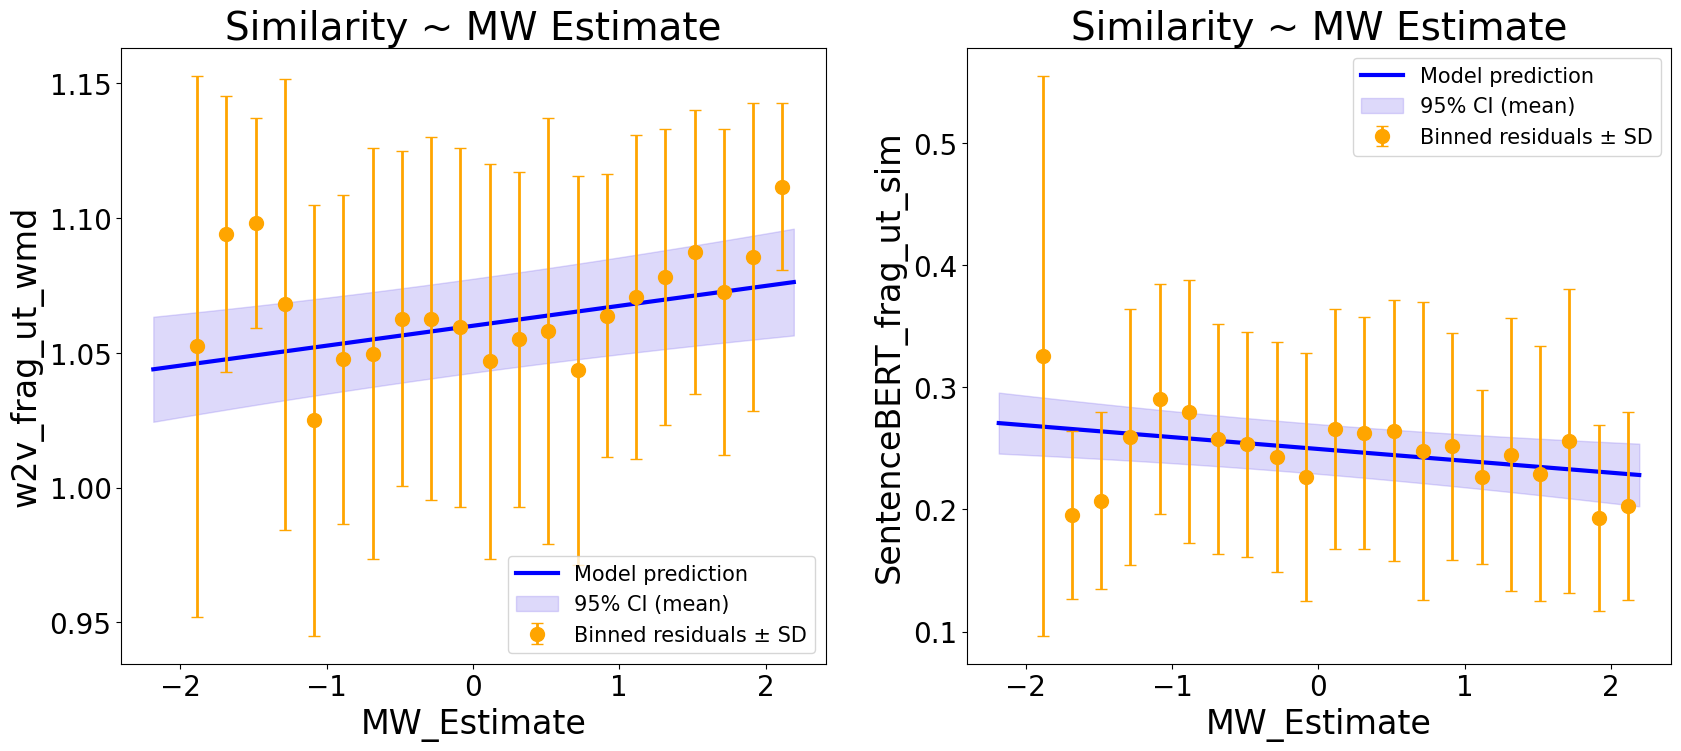

In [28]:
currentDf_pl = currentDf.copy()

currentDf_pl = currentDf_pl[(currentDf_pl['MW_Estimate'] < 2.2) & (currentDf_pl['MW_Estimate'] >-2.2)]

currentDf_pl['trialNum_centered'] = currentDf_pl['trialNum'] - currentDf_pl['trialNum'].mean()
currentDf_pl['lemmaN_centered'] = currentDf_pl['lemmaN'] - currentDf_pl['lemmaN'].mean()



m11 = smf.mixedlm("w2v_frag_ut_wmd ~ MW_Estimate  +trialNum_centered+lemmaN_centered", data=currentDf_pl,
                groups="DS",  # Random intercept
                ).fit()
print(m11.summary())


m12 = smf.mixedlm("SentenceBERT_frag_ut_sim ~ MW_Estimate  +trialNum_centered+lemmaN_centered", data=currentDf_pl,
                groups="DS",  # Random intercept
                ).fit()
print(m12.summary())
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
plot_mw_predicted( m11, currentDf_pl, ax=ax[0],target='MW_Estimate',yvar='w2v_frag_ut_wmd',binwidth=0.2)
plot_mw_predicted( m12, currentDf_pl, ax=ax[1],target='MW_Estimate',yvar='SentenceBERT_frag_ut_sim',binwidth=0.2)
plt.savefig(os.path.join(savePathFeatures,f"SemanticSim_pred_WMD.svg"))


In [29]:
savePathFeatures

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\SecondExp\\RecallAnalysis\\NewAnalysis_AutobiografyCheck_4_NoShort_sFiltered'

In [30]:
import statsmodels.api  as sm

def linearModelChecks(m,grand_df,formula =  "MW_Estimate ~ Tracking + trialNum"):
    # trial-level diagnostics
    resid   = m.resid                   # raw (conditional) residuals
    fitted  = m.fittedvalues            # conditional fitted values
    std_res = resid / np.sqrt(m.scale)  # ≈ studentised residuals
    fig,axs = plt.subplots(2,1,figsize=(14, 8))
    plt.suptitle("Checks for a Linear Model")

    # (1) Homoscedascisity
    axs[0].scatter(fitted, std_res, alpha=0.6, s=15,color='blue')
    axs[0].axhline(0, linestyle='--',color='orange')
    axs[0].set_xlabel("Fitted value")
    axs[0].set_ylabel("Studentised residual")
    axs[0].set_title("Residuals vs fitted")

    # (2) 
    sm.qqplot(std_res, line="45", fit=True, ax=axs[1])
    axs[1].set_title("Normal Q–Q")

    # (3) Colinearity:
    from patsy import dmatrices

    formula_fixed = formula  # your fixed part
    y, X = dmatrices(formula_fixed, data=grand_df, return_type="dataframe")
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns
    )
    print(vif)

     # Drop the intercept from display (its VIF is usually not meaningful)
    vif_display = vif.drop('Intercept', errors='ignore')
    
    # Convert to multiline string
    vif_text = "\n".join([f"{k}: {v:.2f}" for k, v in vif_display.items()])
    vif_text = f"VIFs\n{vif_text}"

    axs[1].text(
        0.8, 0.5, vif_text,
        transform=axs[1].transAxes,
        verticalalignment='top',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
    )


Intercept      9.850353
MW_Estimate    1.021021
trialNum       1.005736
lemmaN         1.015244
dtype: float64


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


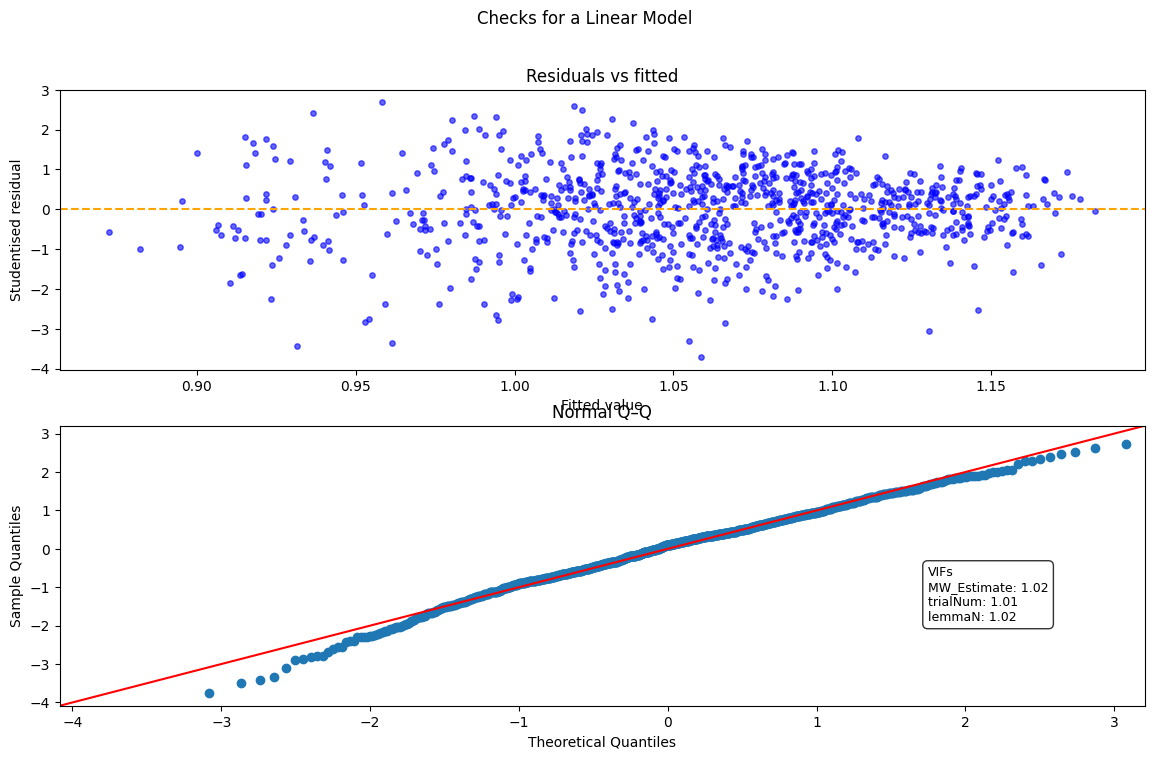

In [31]:
#from analysisFunctions import linearModelChecks
### Checks the assumptioons of a linear model 

m11 = smf.mixedlm("w2v_frag_ut_wmd ~ MW_Estimate  +trialNum_centered+lemmaN_centered", data=currentDf_pl,
                groups="DS",  # Random intercept
                ).fit()
linearModelChecks(m11,currentDf_pl,formula="w2v_frag_ut_wmd ~ MW_Estimate +trialNum+lemmaN ")

KeyError: 'TRACKED'

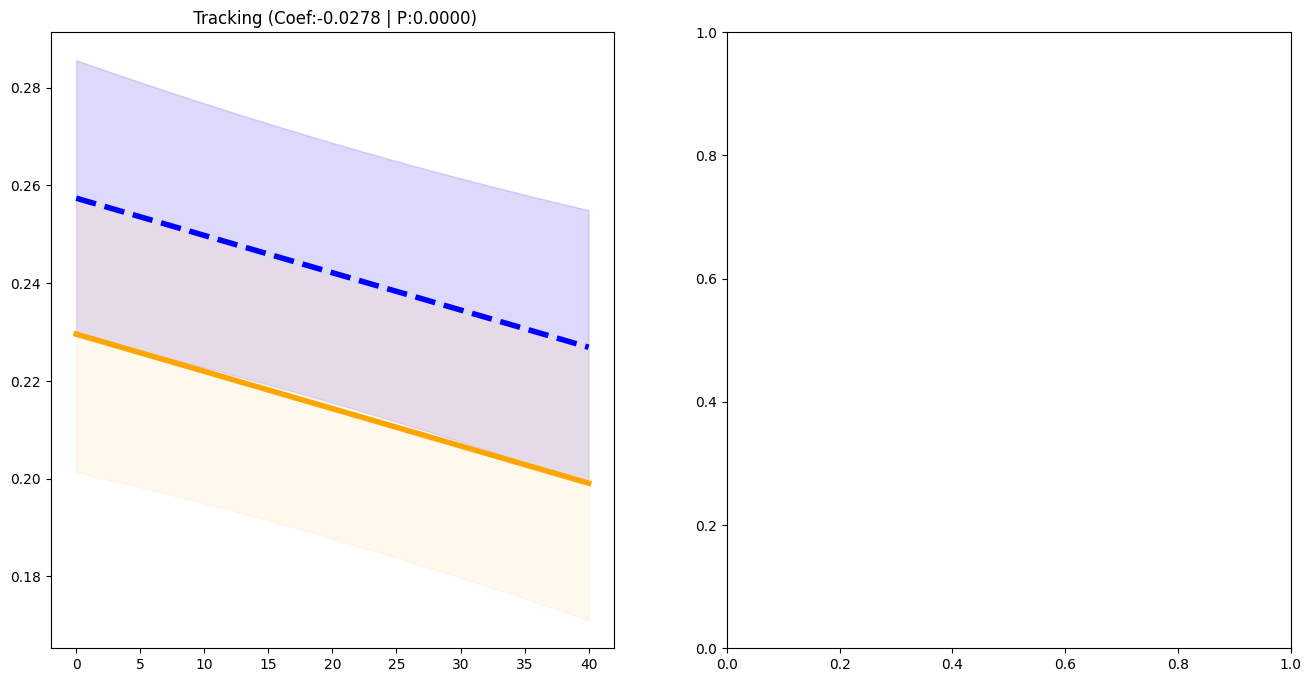

In [32]:
fig, ax = plt.subplots(1,2,figsize=(16, 8))

plotTrialTrack(m1,"SentenceBERT_frag_ut_sim",currentDf,ax[0],titl=f" {'Tracking'} (Coef:{ m1.params[m1.params.keys()[1]]:1.4f} | P:{ m1.pvalues[m1.params.keys()[1]]:1.4f})",anlysisName = "MW_Estimate",)
plotTrialTrack(m2,"SentenceBERT_frag_ut_sim",currentDf,ax[1],titl=f" {'Attention'} (Coef:{ m2.params[m2.params.keys()[1]]:1.4f} | P:{ m2.pvalues[m2.params.keys()[1]]:1.4f})",paramNum=[0,1,2],anlysisName="Attention2",firstContrast=1,lastContrast=3)
#plotTrialTrack(m3,"SentenceBERT_frag_ut_sim",currentDf,ax[2],titl=f" {'SentenceBERT_frag_ut_sim'} (Coef:{ m3.params[m3.params.keys()[1]]:1.4f} | P:{ m3.pvalues[m3.params.keys()[1]]:1.4f})")


plt.savefig(os.path.join(savePathFeatures,f"SemanticSim_ST_Frag.svg"))



### 2. Word2vec Word Mover's Distance:  Story Fragment vs Current Thoughts


#### 1.1 WMD ~ Cued/Uncued + Lemma N + trialNum 







======== Test for MW Estimate vs w2v_frag_ut_wmd =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  w2v_frag_ut_wmd
No. Observations:   1002     Method:              REML           
No. Groups:         26       Scale:               0.0027         
Min. group size:    31       Log-Likelihood:      1471.0209      
Max. group size:    40       Converged:           Yes            
Mean group size:    38.5                                         
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              1.139    0.011 106.559 0.000  1.118  1.160
Tracking[T.UNTRACKED]  0.011    0.003   3.236 0.001  0.004  0.017
trialNum               0.000    0.000   1.824 0.068 -0.000  0.001
lemmaN                -0.006    0.000 -17.213 0.000 -0.006 -0.005
DS Var                 0.002    0.011                            



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


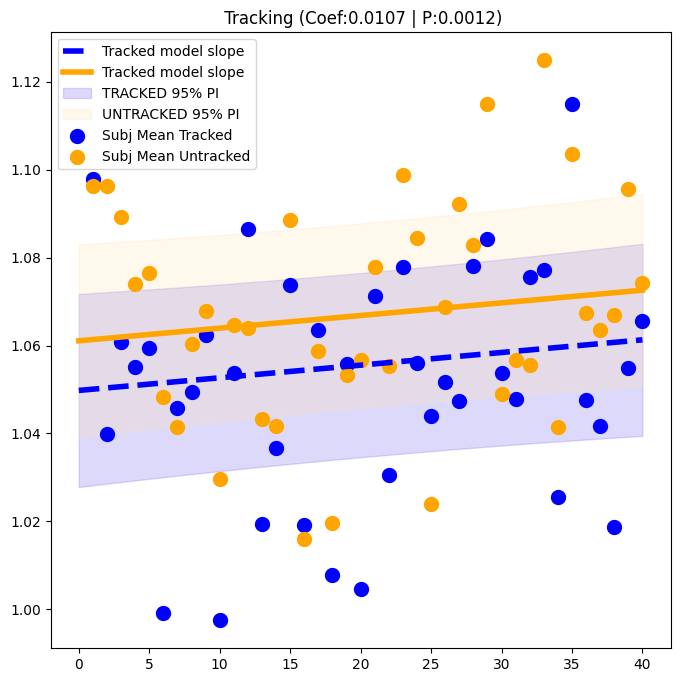

In [ ]:
import statsmodels.formula.api as smf

from analysisFunctions import plot_pupil_vs_mw


print("\n\n=============================================================")
print(f"======== Test for MW Estimate vs {'w2v_frag_ut_wmd'} =======")
print("=============================================================\n")


# Fit the mixed effects model
m1 = smf.mixedlm("w2v_frag_ut_wmd ~ Tracking +trialNum + lemmaN", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()
print(m1.summary())  # ≈ summary(lm(...)) in R

m11 = smf.mixedlm("w2v_frag_ut_wmd ~ Tracking +trialNum ", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()

fig, ax = plt.subplots(figsize=(8, 8))
plotTrialTrack(m11,"w2v_frag_ut_wmd",currentDf,ax,titl=f" {'Tracking'} (Coef:{ m1.params[m1.params.keys()[1]]:1.4f} | P:{ m1.pvalues[m1.params.keys()[1]]:1.4f})")






#### 1.2 WMD  ~ MW Estimate + Lemma N + trialNum 


In [ ]:
import statsmodels.formula.api as smf

from analysisFunctions import plot_pupil_vs_mw


print("\n\n=============================================================")
print(f"======== Test for MW Estimate vs {'w2v_frag_ut_wmd'} =======")
print("=============================================================\n")

# Create the DataFrame and transpose it

# Clean the data
currentDf = currentDf.dropna(subset=['MW_Estimate_bin', 'Tracking', 'trialNum','SentenceBERT_frag_ut_sim','w2v_frag_ut_wmd'])  # Drop rows with NaN


m22 = smf.mixedlm("w2v_frag_ut_wmd ~ C(Attention2)  ", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()
# Fit the mixed effects model
m2 = smf.mixedlm("w2v_frag_ut_wmd ~ C(Attention2)  + trialNum + lemmaN", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()
print(m2.summary())  # ≈ summary(lm(...)) in R





======== Test for MW Estimate vs w2v_frag_ut_wmd =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: w2v_frag_ut_wmd
No. Observations:  1002    Method:             REML           
No. Groups:        26      Scale:              0.0026         
Min. group size:   31      Log-Likelihood:     1487.2379      
Max. group size:   40      Converged:          Yes            
Mean group size:   38.5                                       
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           1.143    0.010 110.868 0.000  1.123  1.163
C(Attention2)[T.3]  0.028    0.004   6.574 0.000  0.019  0.036
trialNum            0.000    0.000   1.631 0.103 -0.000  0.001
lemmaN             -0.006    0.000 -18.245 0.000 -0.007 -0.005
DS Var              0.002    0.010                            



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### 1.3 WMD  ~ Attentiveness + Lemma N + trialNum 


In [ ]:
m3.pvalues

Intercept      0.000000e+00
MW_Estimate    5.312463e-06
trialNum       1.432668e-01
lemmaN         1.015480e-70
DS Var         7.606121e-04
dtype: float64



======== Test for MW Estimate vs w2v_frag_ut_wmd =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: w2v_frag_ut_wmd
No. Observations: 1002    Method:             REML           
No. Groups:       26      Scale:              0.0027         
Min. group size:  31      Log-Likelihood:     1475.3944      
Max. group size:  40      Converged:          Yes            
Mean group size:  38.5                                       
--------------------------------------------------------------
              Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept      1.148     0.011  108.757  0.000   1.128   1.169
MW_Estimate    0.008     0.002    4.552  0.000   0.004   0.011
trialNum       0.000     0.000    1.464  0.143  -0.000   0.000
lemmaN        -0.006     0.000  -17.780  0.000  -0.006  -0.005
DS Var         0.002     0.011                                



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


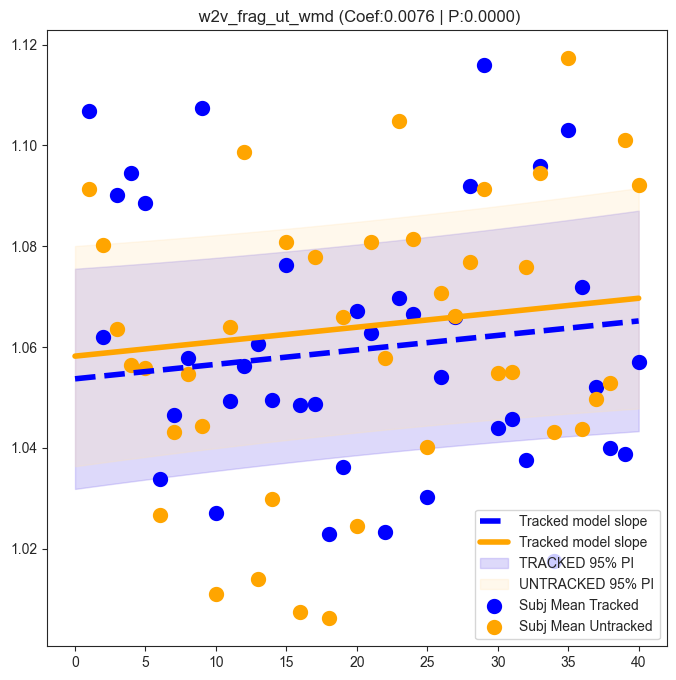

In [ ]:
import statsmodels.formula.api as smf

from analysisFunctions import plot_pupil_vs_mw


print("\n\n=============================================================")
print(f"======== Test for MW Estimate vs {'w2v_frag_ut_wmd'} =======")
print("=============================================================\n")


# Fit the mixed effects model
m3 = smf.mixedlm("w2v_frag_ut_wmd ~ MW_Estimate +trialNum + lemmaN", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()


m33 = smf.mixedlm("w2v_frag_ut_wmd ~C(MW_Estimate_bin) +trialNum ", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()
print(m3.summary())  # ≈ summary(lm(...)) in R
fig, ax = plt.subplots(figsize=(8, 8))


plotTrialTrack(m33,"w2v_frag_ut_wmd",currentDf,ax,titl=f" {'w2v_frag_ut_wmd'} (Coef:{ m3.params[m3.params.keys()[1]]:1.4f} | P:{ m3.pvalues[m3.params.keys()[1]]:1.4f})",paramNum=[0,1,2],anlysisName = 'MW_Estimate_bin',firstContrast=1,lastContrast = 0)



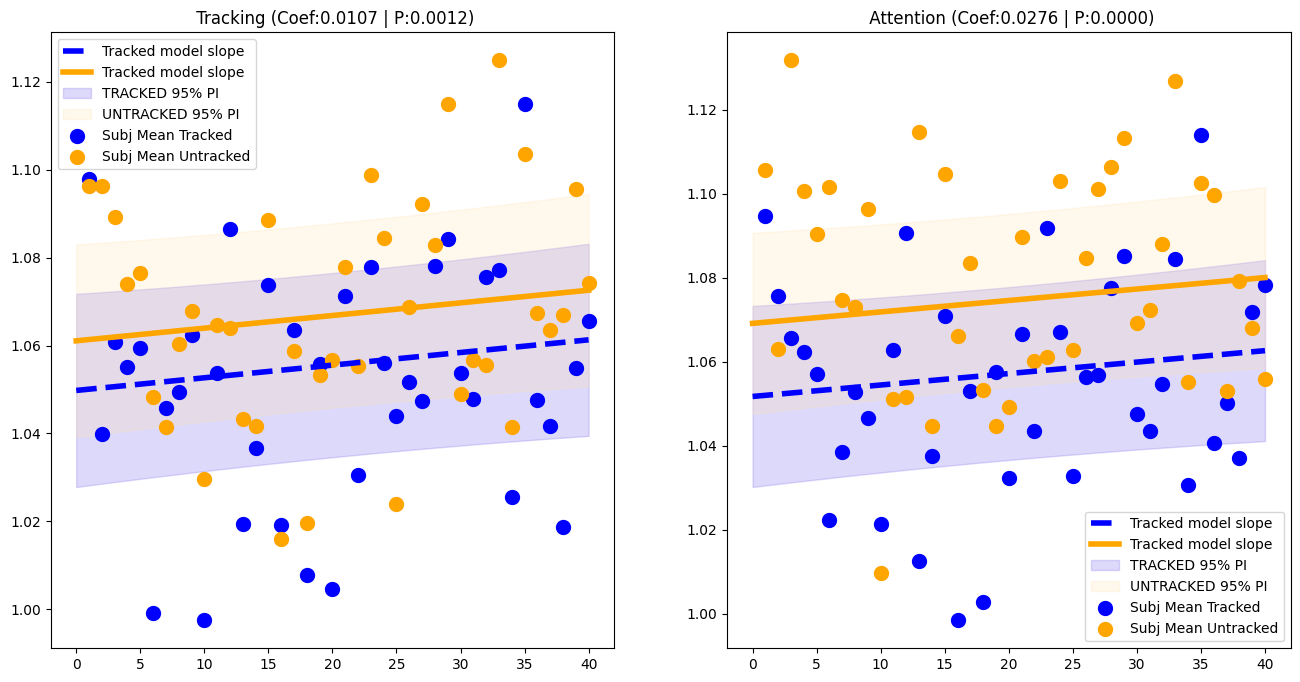

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(16, 8))

plotTrialTrack(m11,"w2v_frag_ut_wmd",currentDf,ax[0],titl=f" {'Tracking'} (Coef:{ m1.params[m1.params.keys()[1]]:1.4f} | P:{ m1.pvalues[m1.params.keys()[1]]:1.4f})")

plotTrialTrack(m22,"w2v_frag_ut_wmd",currentDf,ax[1],titl=f" {'Attention'} (Coef:{ m2.params[m2.params.keys()[1]]:1.4f} | P:{ m2.pvalues[m2.params.keys()[1]]:1.4f})",paramNum=[0,1,2],anlysisName="Attention2",firstContrast=1,lastContrast=3)
#plotTrialTrack(m3,"SentenceBERT_frag_ut_sim",currentDf,ax[2],titl=f" {'SentenceBERT_frag_ut_sim'} (Coef:{ m3.params[m3.params.keys()[1]]:1.4f} | P:{ m3.pvalues[m3.params.keys()[1]]:1.4f})")
plt.savefig(os.path.join(savePathFeatures,f"SemanticWMD_ST_Frag.svg"))


### Autobiographical Features

Here we test whether autobiographical features of Particiapnts utterances differ in Attention and Tracked/Not tracked stories

#### Statistical Note:

Since Language, and especially Word Counts are rarely normally disributed we have utilise new procedures
+ We Cannot use Word Count per -person - since we are interested in the intersection of Attention (Where Innatentive and Attentive are not equivalent)
+ We want to test across participants - So we NEED to account for their Variability
+ Linear Mixed Effects or any other traditional Mixed Effects models will likely NOT SUFFICE - they have the same Assumptions as all other linear models: (Homoscedascisity, Residual being normally distributed  - i.e. our dependent variable, co-linearity). Here, we dont have normal distribution - we have to account for that
+ Counts also have a Distribution that is almost Ordinal-like --> We need to account for that
+ Our Autobiographical words come from utterances of varyign length - therefore number alone often than not is not sufficient


In other words, We need a test that can account for different word count, uneven classess, participants variability and non-normal distributions - and of a kind in which our data will not violate assumptions:\


##### GLMS
We decided upon **Clusteting Generalised Linear Mixed Effects with Wordcount Offset**. Generalized Linear Models operate on the assumptions that dependent Y variable has been DRAWN from a given family of Exponential Distributions (Not just normal). More precisely, we try to find E(Y|X) - which by the way is *expected value* as a LINK FUNCTION ^-1 of our X * Beta linear predictors:


GLM consists of 3 components:
1. Particular Distribution of Y 
2. Linear predictos X*Beta
3. A LINK FUNCTION g so that we LINK our Y variable with selected distributi

The link function provides the relationship between the linear predictor and the mean of the distribution function. There are many commonly used link functions, and their choice is informed by several considerations. Each Cannonical Distribution has its own Link function to pair. For Poisson and Negative Binomial distributio --> LOG is a selected link function:

So we need to find Log(E(X|Y)) = X*Beta!!! 


##### Our Models 
+ We use GLM --> So a model in which we assume and give a distribution of our residulas to fit: 
+ Our Distibution is **NEGATIVE BINOMIAL**
        +  Classic Poisson Distribution, which accounts to amount of rare occurance is not suitable - because it assumes independence of occurance and more importantly has a hard assumption Var(Y) = E(Y) - and in language, ourt Words are NOT independent and are highly varied - moreso that their expected value
        + In similar fashion the classic BINOMIAL whicha ccounts for the probability of a gicen occuerence is also a wrong fit, because it also does not account for jheavy Zero-skewing: 
    
    It is still not ideal, since we assume indpendence of trials drawing Personal Pronouns from the distribution
        + It handles overdispersion
        + It is well suited to Rare events and sekwed distributions!
+ We add OFFSET: so basically aneducated NORMALISATION by lemmaN - but in a way not to destroy statistical interpretation of Negative Binomial"
    
    *log(E[Y])=Xβ+β2​log(LemmaN)*

    *μi​=exp(Xi​β+log(LemmaNi​))*
+ Lastly we add CLUSTERING: Here, clustering works a tad bit differently than in Linear Mixed Effects modelling: Here, we estiamte normally our model with assumption of Indpendence - this is wrong! We know that our variables COMES from different subjects:
        Clusteitng thus replaces COVARIANCE MATRIX: For that we use "sandwich estimator" - Var(β^​)=A−1BA−1 -- Basically, we Estiamte Variance by getting Fisher model tertm: X^T * W * X  = A AND B - which is a residuals per clusters (In our case per subject) - B=j=1∑J​uj​ujT​

        So instead of assuming - Each trial is Independent WE assume that SUBJECTS are INDEPENDENT - but within the subjects we can have corelated observations 

        Mixed Models explicitluy model UJ - and estiamte VARIANCE components and Changes likeliegood - which LCustetring DOES NOT. it DOES NOT change the parameters - However it allows for testing FOR clustrting inside the subjects!! !


#### PERSONAL AND POSSESIVE PRONOUN COUNT

##### **Tracking and Attention**


In [ ]:
### Get new variables for the analysis

currentDf['PersonalVerbCount'] = merged['Personal Verb Count']
currentDf['PersonalPossesivePronounCount'] = merged['pPronCount']

### Normalised for visualisation
currentDf['PPron_Norm'] = currentDf['PersonalPossesivePronounCount'] / currentDf['lemmaN']
currentDf['PVerb_Norm'] = currentDf['PersonalVerbCount'] / currentDf['lemmaN']

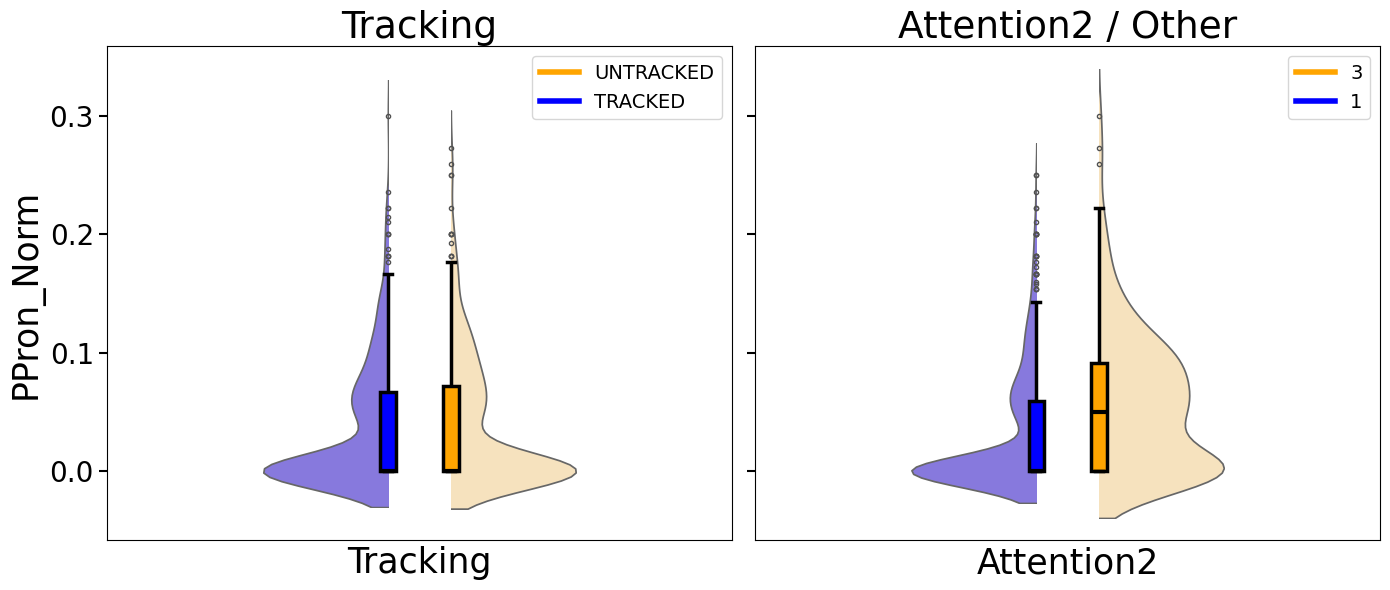

In [ ]:
### PLOTS of Personal Pronounx x Attention and Tracking

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
diffRainPlot(
    df=currentDf,
    x='Tracking',
    y='PPron_Norm',
    ax=axes[0],
    title='Tracking',
    gap=-0.2
)

diffRainPlot(
    df=currentDf,
    x='Attention2',
    y='PPron_Norm',
    ax=axes[1],
    title='Attention2 / Other',
    gap=-0.2

)

plt.tight_layout()
plt.savefig(os.path.join(savePathFeatures,"PPRON_violins.svg"), dpi=300, bbox_inches='tight')

In [ ]:


import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

### Filtering CurrentDF
currentDf2 = currentDf[(currentDf['PersonalPossesivePronounCount'] < 5) ]
# - No more than 5 pronouns in an utterance (to avoid outliers)
# - MW_Estimate within 2 standard deviations (to avoid outliers)

model = smf.glm(
    formula="PersonalPossesivePronounCount ~ Tracking ",
    data=currentDf2,
    family=sm.families.NegativeBinomial(),
    offset=np.log(currentDf2["lemmaN"])
)

result = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": currentDf2["DS"]}
)

print(result.summary())

                       Generalized Linear Model Regression Results                       
Dep. Variable:     PersonalPossesivePronounCount   No. Observations:                  999
Model:                                       GLM   Df Residuals:                      997
Model Family:                   NegativeBinomial   Df Model:                            1
Link Function:                               Log   Scale:                          1.0000
Method:                                     IRLS   Log-Likelihood:                -1009.1
Date:                           Wed, 22 Apr 2026   Deviance:                       712.65
Time:                                   13:53:40   Pearson chi2:                     666.
No. Iterations:                                5   Pseudo R-squ. (CS):          7.303e-05
Covariance Type:                         cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [ ]:


import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

### Filtering CurrentDF
currentDf2 = currentDf[(currentDf['PersonalPossesivePronounCount'] < 7) ]
# - No more than 5 pronouns in an utterance (to avoid outliers)
# - MW_Estimate within 2 standard deviations (to avoid outliers)

model = smf.glm(
    formula="PersonalPossesivePronounCount ~ Attention2 + Tracking",
    data=currentDf2,
    family=sm.families.NegativeBinomial(),
    offset=np.log(currentDf2["lemmaN"])
)

result = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": currentDf2["DS"]}
)

print(result.summary())

                       Generalized Linear Model Regression Results                       
Dep. Variable:     PersonalPossesivePronounCount   No. Observations:                 1001
Model:                                       GLM   Df Residuals:                      998
Model Family:                   NegativeBinomial   Df Model:                            2
Link Function:                               Log   Scale:                          1.0000
Method:                                     IRLS   Log-Likelihood:                -1003.5
Date:                           Wed, 22 Apr 2026   Deviance:                       690.82
Time:                                   11:54:41   Pearson chi2:                     681.
No. Iterations:                                5   Pseudo R-squ. (CS):            0.02720
Covariance Type:                         cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


##### ** MW Estimate **



In [ ]:
currentDf.groupby(['PersonalPossesivePronounCount'])['PersonalPossesivePronounCount'].count()

PersonalPossesivePronounCount
0    583
1    301
2     78
3     24
4     13
5      2
7      1
Name: PersonalPossesivePronounCount, dtype: int64

In [ ]:


import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

### Filtering CurrentDF
currentDf2 = currentDf[(currentDf['PersonalPossesivePronounCount'] < 5) & (currentDf['MW_Estimate'] < 2*np.std(currentDf['MW_Estimate']))]
# - No more than 5 pronouns in an utterance (to avoid outliers)
# - MW_Estimate within 2 standard deviations (to avoid outliers)

model = smf.glm(
    formula="PersonalPossesivePronounCount ~ MW_Estimate +Tracking ",
    data=currentDf2,
    family=sm.families.NegativeBinomial(),
    offset=np.log(currentDf2["lemmaN"])
)

result = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": currentDf2["DS"]}
)

print(result.summary())

                       Generalized Linear Model Regression Results                       
Dep. Variable:     PersonalPossesivePronounCount   No. Observations:                  961
Model:                                       GLM   Df Residuals:                      958
Model Family:                   NegativeBinomial   Df Model:                            2
Link Function:                               Log   Scale:                          1.0000
Method:                                     IRLS   Log-Likelihood:                -969.13
Date:                           Wed, 22 Apr 2026   Deviance:                       683.75
Time:                                   12:49:35   Pearson chi2:                     647.
No. Iterations:                                5   Pseudo R-squ. (CS):           0.006723
Covariance Type:                         cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


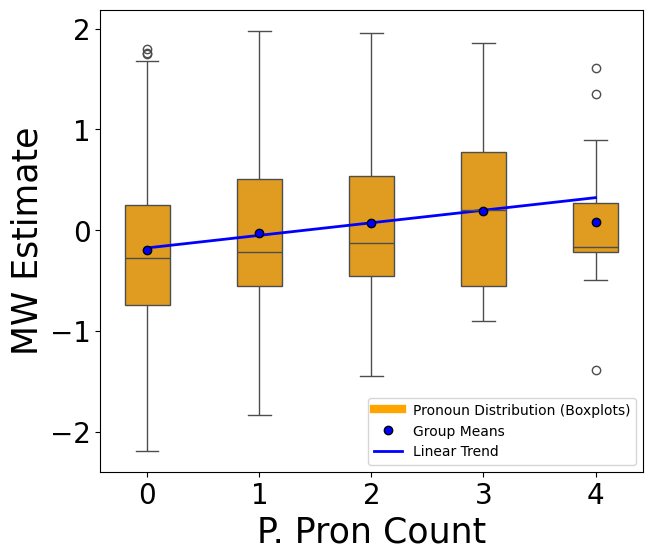

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(
    x='PersonalPossesivePronounCount',
    y='MW_Estimate',
    data=currentDf2,
    ax=ax,
    color='orange',
    width=0.4,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "blue",
        "markeredgecolor": "black",
        "markersize": 6
    }
)

# --- means ---
means = currentDf2.groupby('PersonalPossesivePronounCount')['MW_Estimate'].mean()

x = means.index.values
y = means.values

X = sm.add_constant(x)
model = sm.OLS(y[0:4], X[0:4]).fit()

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = model.predict(sm.add_constant(x_fit))

ax.plot(
    x_fit,
    y_fit,
    color='blue',
    linewidth=2
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
ax.set_xlabel("P. Pron Count", fontsize=25)
ax.set_ylabel("MW Estimate", fontsize=25)
# --- LEGEND (manual) ---
legend_elements = [
    Line2D([0], [0], color='orange', lw=6, label='Pronoun Distribution (Boxplots)'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markeredgecolor='black',
           markersize=6, label='Group Means'),
    Line2D([0], [0], color='blue', lw=2, label='Linear Trend ')
]

ax.legend(handles=legend_elements)

plt.show()

fig.savefig(os.path.join(savePathFeatures,"PPRON_MW_Estimate.svg"), dpi=300, bbox_inches='tight')

#### Personal Verbs

##### **Tracking and Attention**

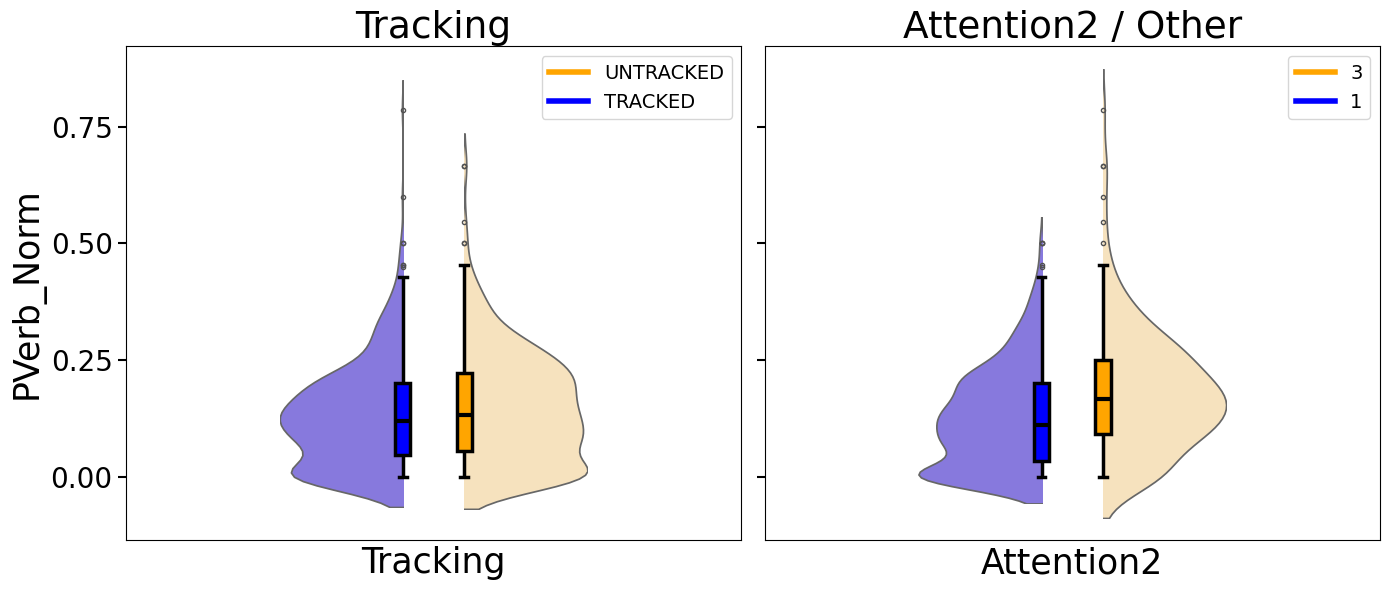

In [ ]:
### PLOTS of Personal Pronounx x Attention and Tracking

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
diffRainPlot(
    df=currentDf,
    x='Tracking',
    y='PVerb_Norm',
    ax=axes[0],
    title='Tracking',
    gap=-0.2
)

diffRainPlot(
    df=currentDf,
    x='Attention2',
    y='PVerb_Norm',
    ax=axes[1],
    title='Attention2 / Other',
    gap=-0.2

)

plt.tight_layout()
plt.savefig(os.path.join(savePathFeatures,"PVERB_violins.svg"), dpi=300, bbox_inches='tight')

In [ ]:
currentDf.groupby(['PersonalVerbCount'])['PersonalVerbCount'].count()

PersonalVerbCount
0     220
1     229
2     201
3     136
4      95
5      52
6      28
7      17
8       7
9      11
10      2
11      3
15      1
Name: PersonalVerbCount, dtype: int64

In [ ]:


import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

### Filtering CurrentDF
currentDf2 = currentDf[(currentDf['PersonalVerbCount'] < 10) ]
# - No more than 5 pronouns in an utterance (to avoid outliers)
# - MW_Estimate within 2 standard deviations (to avoid outliers)

model = smf.glm(
    formula="PersonalVerbCount ~ Tracking ",
    data=currentDf2,
    family=sm.families.NegativeBinomial(),
    offset=np.log(currentDf2["lemmaN"])
)

result = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": currentDf2["DS"]}
)

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      PersonalVerbCount   No. Observations:                  996
Model:                            GLM   Df Residuals:                      994
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1900.7
Date:                Wed, 22 Apr 2026   Deviance:                       651.71
Time:                        12:50:28   Pearson chi2:                     431.
No. Iterations:                     5   Pseudo R-squ. (CS):           0.002132
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -2.05

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [ ]:


import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

### Filtering CurrentDF
currentDf2 = currentDf[(currentDf['PersonalVerbCount'] < 10) ]
# - No more than 5 pronouns in an utterance (to avoid outliers)
# - MW_Estimate within 2 standard deviations (to avoid outliers)

model = smf.glm(
    formula="PersonalVerbCount ~ Attention2 + Tracking",
    data=currentDf2,
    family=sm.families.NegativeBinomial(),
    offset=np.log(currentDf2["lemmaN"])
)

result = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": currentDf2["DS"]}
)

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      PersonalVerbCount   No. Observations:                  996
Model:                            GLM   Df Residuals:                      993
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1893.2
Date:                Wed, 22 Apr 2026   Deviance:                       636.83
Time:                        12:50:41   Pearson chi2:                     423.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01692
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -2.30

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


##### **MIND WANDERING** 

In [ ]:


import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

### Filtering CurrentDF
currentDf2 = currentDf[ (currentDf['PersonalVerbCount'] < 10)& (currentDf['MW_Estimate'] < 2.2*np.std(currentDf['MW_Estimate']))]
# - No more than 5 pronouns in an utterance (to avoid outliers)
# - MW_Estimate within 2 standard deviations (to avoid outliers)

model = smf.glm(
    formula="PersonalVerbCount ~ MW_Estimate ",
    data=currentDf2,
    family=sm.families.NegativeBinomial(),
    offset=np.log(currentDf2["lemmaN"])
)

result = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": currentDf2["DS"]}
)

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      PersonalVerbCount   No. Observations:                  965
Model:                            GLM   Df Residuals:                      963
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1835.9
Date:                Wed, 22 Apr 2026   Deviance:                       631.89
Time:                        14:00:21   Pearson chi2:                     419.
No. Iterations:                     5   Pseudo R-squ. (CS):           0.003241
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.9985      0.098    -20.477      

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [ ]:
currentDf.groupby(['PersonalVerbCount'])['PersonalVerbCount'].count()

PersonalVerbCount
0     220
1     229
2     201
3     136
4      95
5      52
6      28
7      17
8       7
9      11
10      2
11      3
15      1
Name: PersonalVerbCount, dtype: int64

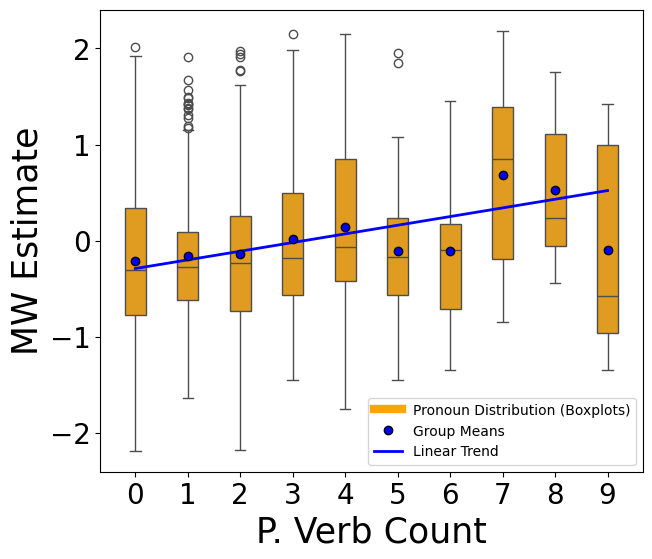

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 6))

sns.boxplot(
    x='PersonalVerbCount',
    y='MW_Estimate',
    data=currentDf2,
    ax=ax,
    color='orange',
    width=0.4,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "blue",
        "markeredgecolor": "black",
        "markersize": 6
    }
)

# --- means ---
means = currentDf2.groupby('PersonalVerbCount')['MW_Estimate'].mean()

x = means.index.values
y = means.values

X = sm.add_constant(x)
model = sm.OLS(y[0:9], X[0:9]).fit()

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = model.predict(sm.add_constant(x_fit))

ax.plot(
    x_fit,
    y_fit,
    color='blue',
    linewidth=2
)

# --- LEGEND (manual) ---
legend_elements = [
    Line2D([0], [0], color='orange', lw=6, label='Pronoun Distribution (Boxplots)'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markeredgecolor='black',
           markersize=6, label='Group Means'),
    Line2D([0], [0], color='blue', lw=2, label='Linear Trend ')
]

ax.legend(handles=legend_elements)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
ax.set_xlabel("P. Verb Count", fontsize=25)
ax.set_ylabel("MW Estimate", fontsize=25)
plt.show()

fig.savefig(os.path.join(savePathFeatures,"PVERB_MW_Estimate.svg"), dpi=300, bbox_inches='tight')

In [ ]:
savePathFeatures

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\SecondExp\\RecallAnalysis\\NewAnalysis_AutobiografyCheck_4_NoShort_sFiltered'

## Plotting

### Semantic Space Plot

In [33]:
# To get the min and max 'Frag-Utt Cosine Sim (Sentance) BERT' for each Fragment,
# along with the corresponding Subject for those values, use idxmin and idxmax
# to find the indices, then retrieve the values and subjects.

# Assuming dfAnalysis is your DataFrame
grouped = merged.groupby('Fragment')

# Get index of min similarity per Fragment
min_idx = grouped['Frag-Utt Cosine Sim (Sentance) BERT'].idxmin()

# Get index of max similarity per Fragment
max_idx = grouped['Frag-Utt Cosine Sim (Sentance) BERT'].idxmax()

# Create result DataFrame
result = pd.DataFrame({
    'Fragment': grouped.groups.keys(),
    'min_sim': merged.loc[min_idx, 'Frag-Utt Cosine Sim (Sentance) BERT'].values,
    'subject_min': merged.loc[min_idx, 'Subject'].values,
    'max_sim': merged.loc[max_idx, 'Frag-Utt Cosine Sim (Sentance) BERT'].values,
    'subject_max': merged.loc[max_idx, 'Subject'].values
})

result

,Fragment,min_sim,subject_min,max_sim,subject_max
0,recall_JANEK_1,0.036442,OSJA1309,0.507206,KLKR2608
1,recall_JANEK_10,0.110463,JUWO0708,0.413754,EDJA1309
2,recall_JANEK_11,0.068968,JUWO0708,0.409448,JAJA2108
3,recall_JANEK_12,0.030627,JUWO0708,0.325356,EWSI2308
4,recall_JANEK_13,0.067903,BAZA2108,0.478170,IZPR2608
5,recall_JANEK_14,0.080334,KAFI2108,0.388968,JAJA2108
6,recall_JANEK_15,0.185605,JUWO0708,0.388004,ANSW1409
7,recall_JANEK_16,0.082094,JUWO0708,0.393576,JAJA2108
8,recall_JANEK_17,0.123307,BAZA2108,0.458910,JAJA2108
9,recall_JANEK_18,0.045117,OSJA1309,0.464618,ANLU2607


CANDIDATES:

1. recall_JANEK_18: min: OSJA1309 ; max: ANLU2607 
2. recall_JANEK_19: min PASZ2608  ; max: ANLU2607
3. recall_KAROLINA_12: min BAZA2108; max: ADNA2507
4. recall_KAROLINA_15: min BAZA2108; max BEWA2308
5. recall_KAROLINA_16: min BAZA2108; max MOWA1009 
6. recall_KAROLINA_17: min BAZA2108; max BEWA2308 
7. recall_KAROLINA_18: min MANI2607; max ADNA2507 
8. recall_KAROLINA_7: min BAZA2108 ; max IZPR2608 

In [34]:
import textwrap

for (idx, row),fragm in zip(result.iterrows(),dfData['StoryFrag'].unique()):
    print(f"\n===Fragment: {row['Fragment']}===\n")
    print(textwrap.fill(f"Utterance: {fragm}", width = 80))
    print(f"\n Minimum Subject: {row['subject_min']} with Similarity: {row['min_sim']:.4f}")
    print(textwrap.fill(f"Minimum: {dfData[(dfData['Subject'] == row['subject_min']) & (dfData['Fragment'] == row['Fragment']) ]['Utterance'].values[0]}",width=80))

    print(f"\n Maximum Subject: {row['subject_max']} with Similarity: {row['max_sim']:.4f}")
    print(textwrap.fill(f"Maximum: {dfData[(dfData['Subject'] == row['subject_max']) & (dfData['Fragment'] == row['Fragment']) ]['Utterance'].values[0]}",width=80))


===Fragment: recall_JANEK_1===

Utterance: Janek - brat Karoliny, zdolny cieśla o zręcznych dłoniach i sercu
większym niż portowy skład drewna, również marzył o czymś więcej. Pragnął
własnego warsztatu – miejsca, gdzie mógłby tworzyć rzeczy trwałe, z duszą. Na
razie zadowalał się naprawami dla sąsiadów, marząc o dniu, gdy stanie się
czeladnikiem. “Czasem czuję żal, ale wierzę, że uczciwa praca w końcu zostanie
zauważona” - przyznał siostrze. Wspominał ich ojca, który również był cieślą,
który mawiał, że uczciwe ręce są więcej warte niż sakiewka złota. Mimo że Jan
odkładał monety na swój zakład, nie wahał się pomagać potrzebującym i
niejednokrotnie odłożony grosz przeznaczał na ubogich.

 Minimum Subject: OSJA1309 with Similarity: 0.0364
Minimum:  To myślałem o tym, że już się trochę przyzwyczaiłem do tego głosu AI,
chociaż jest bardzo nieludzki, nie intonuje ludzko w ogóle swoich słów i
wypowiedzi, co jest po prostu nieprzyjemne do słuchania i miałem myśli o tym,
jak to ludzki organiz

In [ ]:
merged[(merged['Subject'] == 'NIZA2907')& (merged['Fragment'] == 'recall_JANEK_13')]['Frag-Utt Cosine Sim (Sentance) BERT']

875    0.179082
Name: Frag-Utt Cosine Sim (Sentance) BERT, dtype: float64

In [ ]:
print(dfData[dfData['Fragment'] == 'recall_JANEK_13'][['Subject','Fragment','Utterance','StoryFrag']].to_string())

       Subject         Fragment                                                                                                                                                                                                                                                                                                                                                                                                                                                                   Utterance                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [35]:
### BERT embedding computation:

import torch
from sentence_transformers import SentenceTransformer, util
embeddModel = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

def bertEmbedding(text,model):
    """
    Quick BertCosine  Similarity Catered towards Sentence Embeddings. But Works also for Lemmas 
    (providing they have been properly filtered)

    It is Not Fancy at all, i
    """
    ### Sanity: Remove empty tokens:
    text = [t for t in text if t != " " and t != ' ']
    # print(text1)
    # --- encode all sentences in one batch ---

    E = model.encode(text, convert_to_tensor=True, normalize_embeddings=True)  # [F+U, D]
    return E

In [36]:
embedds_test = bertEmbedding(dfData['Utterance'].to_list(),embeddModel).cpu().numpy()
embedDF = pd.DataFrame(embedds_test,columns=[f'BERT_Dim_{i}' for i in range(embedds_test.shape[1])])
embedDF['Fragment'] = dfData['Fragment'].values
embedDF['Subject'] = dfData['Subject'].values
cols = ['Fragment', 'Subject'] + [c for c in embedDF.columns if c not in ['Fragment', 'Subject']]
embedDF = embedDF[cols]
embedDF

,Fragment,Subject,BERT_Dim_0,BERT_Dim_1,BERT_Dim_2,BERT_Dim_3,BERT_Dim_4,BERT_Dim_5,BERT_Dim_6,BERT_Dim_7,...,BERT_Dim_374,BERT_Dim_375,BERT_Dim_376,BERT_Dim_377,BERT_Dim_378,BERT_Dim_379,BERT_Dim_380,BERT_Dim_381,BERT_Dim_382,BERT_Dim_383
0,recall_JANEK_1,ADNA2507,0.010000,0.140525,-0.051235,0.002522,-0.027433,-0.027329,0.086214,-0.029443,...,0.066160,-0.101948,-0.026673,0.050295,-0.044034,-0.043995,0.102748,-0.023229,0.058134,0.029680
1,recall_JANEK_10,ADNA2507,-0.038277,0.008879,0.015663,0.045808,-0.052762,-0.107891,0.042762,-0.022332,...,0.006904,-0.037871,0.029014,0.012675,-0.019772,0.016086,0.038725,0.017726,0.003212,0.015993
2,recall_JANEK_11,ADNA2507,-0.018795,0.068230,0.082846,-0.020434,-0.053983,-0.114598,-0.007054,0.008643,...,-0.073851,0.057730,-0.018245,0.001808,-0.079019,0.004163,0.050860,0.008468,0.030226,0.076871
3,recall_JANEK_12,ADNA2507,0.061692,0.002608,-0.046910,0.039048,0.023908,-0.041494,0.006399,0.001935,...,0.065724,-0.039091,0.002814,-0.026960,-0.055050,0.034145,0.019113,0.089330,-0.036927,0.020006
4,recall_JANEK_13,ADNA2507,0.009582,0.055624,0.035213,0.035862,0.046963,-0.094972,-0.032478,-0.012976,...,-0.023425,-0.030512,-0.010980,0.007144,-0.063480,-0.021625,-0.009529,0.038472,0.016802,0.043510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,recall_KAROLINA_5,TYTO1309,0.019306,-0.038600,-0.045682,0.078560,-0.006851,-0.005235,-0.038123,0.033714,...,-0.020034,-0.031033,0.040443,0.060374,-0.096276,-0.032798,0.054125,0.025151,-0.075151,-0.023767
1121,recall_KAROLINA_6,TYTO1309,0.047282,0.017984,0.006505,0.037973,0.053020,-0.050386,0.030859,0.022845,...,0.089268,-0.005376,-0.026284,0.062057,-0.051935,-0.022341,0.025116,0.078623,-0.109907,-0.047313
1122,recall_KAROLINA_7,TYTO1309,0.027261,-0.047526,-0.001504,0.025875,0.016411,-0.006019,-0.024052,0.000048,...,0.102206,0.005371,-0.007358,0.093735,-0.122926,-0.041242,-0.026525,0.000033,-0.133138,-0.047500
1123,recall_KAROLINA_8,TYTO1309,0.122069,-0.000834,0.040779,0.056976,0.013689,-0.089643,0.044137,-0.013408,...,0.030891,0.030071,-0.030753,0.125321,-0.066164,0.017296,0.049025,0.100626,-0.091573,-0.040898


In [ ]:
embedDF[embedDF['Fragment'] == 'recall_JANEK_18'][[c for c in embedDF.columns if c not in ['Fragment', 'Subject']]]

,BERT_Dim_0,BERT_Dim_1,BERT_Dim_2,BERT_Dim_3,BERT_Dim_4,BERT_Dim_5,BERT_Dim_6,BERT_Dim_7,BERT_Dim_8,BERT_Dim_9,...,BERT_Dim_374,BERT_Dim_375,BERT_Dim_376,BERT_Dim_377,BERT_Dim_378,BERT_Dim_379,BERT_Dim_380,BERT_Dim_381,BERT_Dim_382,BERT_Dim_383
9,0.006723,0.023737,-0.041557,-0.004544,-0.047242,0.032168,0.066286,0.007863,-0.025193,0.007638,...,0.071565,-0.075720,0.016114,0.093506,-0.080797,-0.063406,0.046105,0.077669,-0.034837,0.002243
49,0.020340,0.063877,-0.012273,-0.017284,0.011472,-0.007439,-0.012622,0.013889,0.067183,-0.021320,...,0.072077,0.025177,-0.036553,0.089646,-0.076988,-0.008417,0.017533,0.004564,-0.037147,-0.010401
89,0.042113,0.037801,-0.036937,-0.018643,-0.016590,-0.005914,0.050268,0.032916,-0.003486,0.043720,...,0.081780,-0.033796,0.030934,0.015685,-0.048515,-0.010692,0.005858,0.031238,-0.091313,0.022776
146,0.064900,-0.015916,0.021988,0.038960,0.014857,-0.039503,-0.029196,0.054719,0.046012,-0.069491,...,0.040959,-0.013662,0.027599,0.063021,-0.114941,-0.001562,0.011353,0.007641,-0.082693,-0.038747
186,0.019122,0.021423,-0.043416,0.008799,0.032740,0.006607,0.045879,-0.002794,0.053056,-0.020432,...,0.082225,0.009099,0.004500,0.074178,-0.065951,-0.022616,0.003789,0.050271,-0.089080,0.003206
226,-0.038800,-0.027533,0.006090,-0.004573,-0.020967,-0.049769,0.054394,0.004922,-0.010182,-0.003191,...,0.097938,-0.035871,0.051442,-0.013393,-0.085924,0.036679,0.121020,0.088515,0.010593,0.014375
265,0.005049,0.029926,-0.034352,0.014928,0.041509,-0.074114,0.011388,-0.065180,0.065361,-0.018624,...,0.021012,0.005382,0.021306,0.082681,-0.064173,-0.002346,0.005132,0.039075,-0.079390,-0.005395
301,0.059974,-0.004937,0.086448,0.002585,-0.003395,-0.065623,0.054494,0.031674,-0.004105,-0.007468,...,0.084574,-0.043021,-0.053911,0.084032,-0.132398,-0.008306,0.095633,0.016544,-0.033100,-0.068960
340,-0.005180,-0.034843,-0.001222,-0.012920,-0.035687,-0.085209,-0.060023,-0.031503,0.015742,-0.020535,...,0.102097,0.114149,0.031242,-0.023243,-0.106688,0.046693,0.064930,0.024586,-0.040854,-0.025875
377,0.041910,-0.032299,0.029975,0.012333,-0.008687,-0.043676,-0.006967,0.054321,-0.005038,-0.099436,...,0.100681,-0.028050,0.021971,0.083666,-0.164428,-0.017132,0.058602,0.006252,-0.062169,-0.029236


In [37]:
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from plotly.subplots import make_subplots
from scipy.spatial import ConvexHull
import textwrap
def visualize_fragment_vs_subjects_blob(
    df,
    fragment_text,
    fragment,
    subject1,
    subject2,
    model,
    label1=None,
    label2=None,
    camera=None,
    sem_dist1=None,
    sem_dist2=None,
    plot_name=None,
    axis_order=None,
    good_recall_text = "",
    mind_wandering_text = "",
):
    
    axis_label = ["PC1", "PC2", "PC3"]

    if label1 is None:
        label1 = subject1

    if label2 is None:
        label2 = subject2

    if camera is None:
        camera = dict(
            eye=dict(x=1.8, y=1.2, z=1.0),
            center=dict(x=0, y=0, z=0),
            up=dict(x=0, y=0, z=1)
        )
    if plot_name is None:
        plot_name = "semantic_view"

    if axis_order is  None:
        axis_order = [0,1,2]
    emb_cols = [c for c in df.columns if c.startswith("BERT_Dim_")]
    X = df[emb_cols].values

    # --- PCA (globalne) ---
    pca = PCA(n_components=3, random_state=42)
    X_3d = pca.fit_transform(X)

    # --- embedding fragmentu ---
    frag_emb = model.encode(
        [fragment_text],
        convert_to_tensor=False,
        normalize_embeddings=True
    )
    frag_3d = pca.transform(frag_emb)

    # --- maski ---
    mask_s1 = (df["Fragment"] == fragment) & (df["Subject"] == subject1)
    mask_s2 = (df["Fragment"] == fragment) & (df["Subject"] == subject2)

    fig = go.Figure()

    ### Set up camera
    fig.update_layout(
        scene_camera=dict(
            eye=dict(x=1.8, y=1.2, z=1.0),
            center=dict(x=0, y=0, z=0),
            up=dict(x=0, y=0, z=1)
        )
    )

    # =========================
    # 1. SEMANTIC BLOB
    # =========================
    fig.add_trace(go.Mesh3d(
        x=X_3d[:, axis_order[0]],
        y=X_3d[:, axis_order[1]],
        z=X_3d[:, axis_order[2]],
        alphahull=5,
        opacity=0.25,
        color='mediumslateblue',
        name='Semantic space',
        showscale=False
    ))

    # =========================
    # 2. FRAGMENT
    # =========================
    fig.add_trace(go.Scatter3d(
        x=[frag_3d[0, axis_order[0]]],
        y=[frag_3d[0, axis_order[1]]],
        z=[frag_3d[0, axis_order[2]]],
        mode='markers+text',
        textposition='bottom center',
        text="",#['Story Fragment'],
        marker=dict(size=10, color='blue'),
        name='Fragment'
    ))

    # =========================
    # 3. SUBJECT 1
    # =========================
    fig.add_trace(go.Scatter3d(
        x=X_3d[mask_s1, axis_order[0]],
        y=X_3d[mask_s1, axis_order[1]],
        z=X_3d[mask_s1, axis_order[2]],
        mode='markers+text',
        textposition='bottom center',
        text="",
        marker=dict(size=8, color='orange'),
        name=subject1
    ))

    # =========================
    # 4. SUBJECT 2
    # =========================
    fig.add_trace(go.Scatter3d(
        x=X_3d[mask_s2, axis_order[0]],
        y=X_3d[mask_s2, axis_order[1]],
        z=X_3d[mask_s2, axis_order[2]],
        mode='markers+text',
        textposition='bottom center',
        text="",
        marker=dict(size=8, color='purple'),
        name=subject2
    ))

    # =========================================================
    # ✔️ DODANE: REPREZENTANTY (bez tego linie nie mają sensu)
    # =========================================================

    # najbliższy punkt S1 względem fragmentu
    idx1 = np.argmin(np.linalg.norm(X_3d[mask_s1] - frag_3d, axis=1))
    s1_point = X_3d[mask_s1][idx1]

    # najbliższy punkt S2 względem fragmentu
    idx2 = np.argmin(np.linalg.norm(X_3d[mask_s2] - frag_3d, axis=1))
    s2_point = X_3d[mask_s2][idx2]

    # =========================
    # 5. WECTOR FRAGMENT → S1
    # =========================
    fig.add_trace(go.Scatter3d(
        x=[frag_3d[0,axis_order[0]], s1_point[axis_order[0]]],
        y=[frag_3d[0,axis_order[1]], s1_point[axis_order[1]]],
        z=[frag_3d[0,axis_order[2]], s1_point[axis_order[2]]],
        mode='lines+text',
        line=dict(color='orange', width=6),
        text="", #["", str(sem_dist1) if sem_dist1 is not None else ""],
        textposition="top center",
        name="Fragment → Subject1"
    ))

    # =========================
    # ✔️ DODANE: FRAGMENT → S2
    # =========================
    fig.add_trace(go.Scatter3d(
        x=[frag_3d[0,axis_order[0]], s2_point[axis_order[0]]],
        y=[frag_3d[0,axis_order[1]], s2_point[axis_order[1]]],
        z=[frag_3d[0,axis_order[2]], s2_point[axis_order[2]]],
        mode='lines',
        line=dict(color='purple', width=6),
        name="Fragment → Subject2"
    ))

    # =========================
    # 6. LAYOUT
    # =========================
    fig.update_layout(
        title="Semantic space",
        scene=dict(
            xaxis=dict(
                title=dict(
                    text=axis_label[axis_order[0]],
                    font=dict(size=20)
                ),
                nticks=4,
                tickfont=dict(size=16),
                showbackground=True,
                backgroundcolor='moccasin',  # moccasin + alpha
                gridcolor='black'

            ),
            yaxis=dict(
                title=dict(
                    text=axis_label[axis_order[1]],
                    font=dict(size=20)
                ),                
                nticks=4,
                tickfont=dict(size=16),
                showbackground=True,
                backgroundcolor='antiquewhite',  # moccasin + alpha
                gridcolor='black'

            ),
            zaxis=dict(
                title=dict(
                    text=axis_label[axis_order[2]],
                    font=dict(size=20)
                ),
                nticks=4,
                tickfont=dict(size=16),
                showbackground=True,
                backgroundcolor='floralwhite',  # moccasin + alpha
                gridcolor='black'

            ),
            aspectmode="cube"
        ),
        scene_camera=camera,
        margin=dict(l=0, r=0, t=40, b=0)
    )
    def wrap_html(text, width=60):
        import textwrap
        return "<br>".join(textwrap.wrap(text, width=width))

    fig.add_annotation(
        text=f"<b>Fragment</b><br>{wrap_html(fragment_text, 60)}",
        align="left",
        showarrow=False,
        xref="paper",
        yref="paper",
        x=1.02,
        y=0.85,
        bordercolor="blue",
        borderwidth=2,
        bgcolor="rgba(0,0,255,0.05)"
    )

    fig.add_annotation(
        text=f"<b>Good Recall (purple)</b><br>{wrap_html(good_recall_text, 60)}",
        align="left",
        showarrow=False,
        xref="paper",
        yref="paper",
        x=1.02,
        y=0.45,
        bordercolor="purple",
        borderwidth=2,
        bgcolor="rgba(128,0,128,0.06)"
    )

    fig.add_annotation(
        text=f"<b>Mind Wandering (orange)</b><br>{wrap_html(mind_wandering_text, 60)}",
        align="left",
        showarrow=False,
        xref="paper",
        yref="paper",
        x=1.02,
        y=0.25,
        bordercolor="orange",
        borderwidth=2,
        bgcolor="rgba(255,165,0,0.08)" 
    )
    # export (ZOSTAWIONE jak masz)
    fig.write_image(f".\\SecondExp\\{plot_name}.svg")
    fig.write_html(f".\\SecondExp\\{plot_name}.html")
    fig.show()


    # =========================
    # HULL helper
    # =========================
    def add_hull_2d(fig, points_2d, col, color="mediumslateblue", opacity=0.30):
        if len(points_2d) < 3:
            return

        hull = ConvexHull(points_2d)
        hull_pts = points_2d[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])  # zamknięcie

        fig.add_trace(go.Scatter(
            x=hull_pts[:, 0],
            y=hull_pts[:, 1],
            mode='lines',
            line=dict(color=color, width=2),
            fill='toself',
            fillcolor=color,
            opacity=opacity,
            showlegend=False
        ), row=1, col=col)


    # =========================
    # FIGURE
    # =========================
    fig2d = make_subplots(
        rows=1, cols=3,
        subplot_titles=[
            f"{axis_label[axis_order[0]]} vs {axis_label[axis_order[1]]}",
            f"{axis_label[axis_order[0]]} vs {axis_label[axis_order[2]]}",
            f"{axis_label[axis_order[1]]} vs {axis_label[axis_order[2]]}"
        ]
    )

    # =========================
    # PROJECTION FUNC
    # =========================
    def add_projection(col, dim_x, dim_y):

        # --- wszystkie punkty ---
        points_2d = np.column_stack([
            X_3d[:, dim_x],
            X_3d[:, dim_y]
        ])

        # HULL (globalny)
        add_hull_2d(fig2d, points_2d, col)

    
        # --- fragment ---
        fig2d.add_trace(go.Scatter(
            x=[frag_3d[0, dim_x]],
            y=[frag_3d[0, dim_y]],
            mode='markers',
            marker=dict(size=10, color='blue'),
            name='Fragment' if col == 1 else None,
            showlegend=(col == 1)
        ), row=1, col=col)

        # --- subject1 ---
        fig2d.add_trace(go.Scatter(
            x=X_3d[mask_s1, dim_x],
            y=X_3d[mask_s1, dim_y],
            mode='markers',
            marker=dict(size=8, color='orange'),
            name=label1 if col == 1 else None,
            showlegend=(col == 1)
        ), row=1, col=col)

        # --- subject2 ---
        fig2d.add_trace(go.Scatter(
            x=X_3d[mask_s2, dim_x],
            y=X_3d[mask_s2, dim_y],
            mode='markers',
            marker=dict(size=8, color='purple'),
            name=label2 if col == 1 else None,
            showlegend=(col == 1)
        ), row=1, col=col)

        # --- linia S1 ---
        fig2d.add_trace(go.Scatter(
            x=[frag_3d[0, dim_x], s1_point[dim_x]],
            y=[frag_3d[0, dim_y], s1_point[dim_y]],
            mode='lines',
            line=dict(color='orange', width=3),
            showlegend=False
        ), row=1, col=col)

        # --- linia S2 ---
        fig2d.add_trace(go.Scatter(
            x=[frag_3d[0, dim_x], s2_point[dim_x]],
            y=[frag_3d[0, dim_y], s2_point[dim_y]],
            mode='lines',
            line=dict(color='purple', width=3),
            showlegend=False
        ), row=1, col=col)


    # =========================
    # 3 PROJEKCJE
    # =========================
    add_projection(1, axis_order[0], axis_order[1])
    add_projection(2, axis_order[0], axis_order[2])
    add_projection(3, axis_order[1], axis_order[2])


    # =========================
    # LAYOUT
    # =========================
    fig2d.update_layout(
        title="2D projections of semantic space",
        height=600,
        width=1800,
        margin=dict(l=40, r=40, t=60, b=40),
    )

    # =========================
    # 2D STYLE FIX (VALID PLOTLY)
    # =========================

    fig2d.update_layout(
        plot_bgcolor='floralwhite'
    )

    for axis_name in fig2d.layout:

        if "xaxis" in axis_name or "yaxis" in axis_name:
            fig2d.layout[axis_name].update(
                showgrid=True,
                gridcolor='black',
                zeroline=False,
                tickfont=dict(size=16),
                ticks="outside",
                nticks=4
            )
    # =========================
    # EXPORT
    # =========================
    fig2d.write_image(f".\\SecondExp\\{plot_name}_2D.svg")


    



In [38]:
### View 1
camera1 = {
    "eye": {
        "x": -1.6218464133855663,
        "y": -1.4199177729014472,
        "z": 0.9014851058553108
    },
    "center": {
        "x": -0.0031627126861135117,
        "y": 0.005576979951875184,
        "z": -0.2
    },
    "up": {
        "x": 0,
        "y": 0,
        "z": 1
    }
}

### View 2
camera2= {
    "eye": {
        "x":  1.471781252316772,
        "y": 1.6011205831844053,
        "z": 0.974819379901787
    },
    "center": {
        "x": 0 ,
        "y": 0,
        "z": -0.2
    },
    "up": {
        "x": 0,
        "y": 0,
        "z": 1
    }
}

### View 3
camera3= {
    "eye": {
        "x":  1.9998797708230809,
        "y": -0.9428773984969371,
        "z":  0.9051655376535148
    },
    "center": {
        "x": 0 ,
        "y": 0,
        "z": -0.2
    },
    "up": {
        "x": 0,
        "y": 0,
        "z": 1
    }
}


In [39]:
# good views: Camera 3= [0,2,1], [2,0,1], [1,0,2]
#             Camera 1= [1,2,0], [0,2,1], 
#             Gold Standards: [0,1,2] Camera1; JANEK_18; OSJA1309 vs ANLU2607

import plotly.io as pio
pio.renderers.default = "browser"
visualize_fragment_vs_subjects_blob(
    df=embedDF,
    fragment_text=dfData[dfData['Fragment'] =="recall_JANEK_19"]['StoryFrag'].iloc[0],
    fragment="recall_JANEK_19",
    subject1="PASZ2608",
    subject2="ANLU2607",
    model=embeddModel,
    label2='Focus',
    label1='Mind Wandering',
    camera=camera1,
    plot_name="semantic_view_2_cam1",
    axis_order=[0,1,2],
    good_recall_text=dfData[(dfData['Subject'] == 'ANLU2607') & (dfData['Fragment'] == 'recall_JANEK_19')]['Utterance'].values[0],
    mind_wandering_text=dfData[(dfData['Subject'] == 'PASZ2608') & (dfData['Fragment'] == 'recall_JANEK_19')]['Utterance'].values[0]
)

#PASZ2608  ; max: ANLU2607

In [ ]:
import numpy as np
import plotly.graph_objects as go
import umap

def visualize_fragment_vs_subjects_umap(
    df,
    fragment_text,
    fragment,
    subject1,
    subject2,
    model
):

    emb_cols = [c for c in df.columns if c.startswith("BERT_Dim_")]
    X = df[emb_cols].values

    # =========================
    # UMAP zamiast PCA
    # =========================
    reducer = umap.UMAP(
        n_components=3,
        n_neighbors=15,
        min_dist=0.1,
        metric='cosine',
        random_state=42
    )

    X_3d = reducer.fit_transform(X)

    # embedding fragmentu
    frag_emb = model.encode(
        [fragment_text],
        convert_to_tensor=False,
        normalize_embeddings=True
    )

    frag_3d = reducer.transform(frag_emb)

    # maski
    mask_s1 = (df["Fragment"] == fragment) & (df["Subject"] == subject1)
    mask_s2 = (df["Fragment"] == fragment) & (df["Subject"] == subject2)

    fig = go.Figure()

    # blob (UMAP space)
    fig.add_trace(go.Mesh3d(
        x=X_3d[:, 0],
        y=X_3d[:, 1],
        z=X_3d[:, 2],
        alphahull=5,
        opacity=0.25,
        color='mediumslateblue',
        name='Semantic UMAP space',
        showscale=False
    ))

    # fragment
    fig.add_trace(go.Scatter3d(
        x=[frag_3d[0, 0]],
        y=[frag_3d[0, 1]],
        z=[frag_3d[0, 2]],
        mode='markers+text',
        text="",#['FRAGMENT'],
        marker=dict(size=10, color='blue'),
        name='Fragment'
    ))

    # subject 1
    fig.add_trace(go.Scatter3d(
        x=X_3d[mask_s1, 0],
        y=X_3d[mask_s1, 1],
        z=X_3d[mask_s1, 2],
        mode='markers+text',
        text="",#df[mask_s1]["Subject"],
        marker=dict(size=8, color='orange'),
        name=subject1
    ))

    # subject 2
    fig.add_trace(go.Scatter3d(
        x=X_3d[mask_s2, 0],
        y=X_3d[mask_s2, 1],
        z=X_3d[mask_s2, 2],
        mode='markers+text',
        text= "",# df[mask_s2]["Subject"],
        marker=dict(size=8, color='purple'),
        name=subject2
    ))

    fig.update_layout(
        title="UMAP semantic space (fragment + subjects)",
        scene=dict(aspectmode='cube')
    )

    fig.show()



visualize_fragment_vs_subjects_umap(
    df=embedDF,
    fragment_text=dfData[dfData['Fragment'] =="recall_JANEK_18"]['StoryFrag'].iloc[0],
    fragment="recall_JANEK_18",
    subject1="OSJA1309",
    subject2="ANLU2607",
    model=embeddModel
)